In [1]:
# ==============================================================================
# 1. IMPORTS & GLOBAL SETUP
# ==============================================================================
import os
import sys
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

# Windows + Jupyter cannot safely fork DataLoader workers: it uses 'spawn',
# which has to re-pickle the in-notebook Dataset/Transform classes and often
# fails with: "DataLoader worker (pid(s) ...) exited unexpectedly".
# We detect this here and force num_workers=0 below.
IS_WINDOWS = sys.platform.startswith("win")

# ── Reproducibility ──────────────────────────────────────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# ── Global Constants ─────────────────────────────────────────────────────────
KAGGLE_DIR = "/kaggle/input/datasets/neuralthon/breast-lesion-segmentation-dataset/Breast_Ultrasound_Dataset"
LOCAL_DIR = "Breast_Ultrasound_Dataset"

if os.path.exists(KAGGLE_DIR):
    DATA_DIR = KAGGLE_DIR
else:
    DATA_DIR = LOCAL_DIR

print(f"[INFO] Using DATA_DIR: {DATA_DIR}")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

IMG_SIZE = 256

# NOTE on hyper-parameters:
# The Swin-UNet uses an ImageNet-pretrained SwinV2-Tiny encoder + a scratch
# decoder. LEARNING_RATE is the DECODER peak LR; the encoder is trained at
# ENCODER_LR_FACTOR * LEARNING_RATE (see training cell) -- typical 10x ratio.
#   * EPOCHS + PATIENCE are generous: BUSI is ~427 images, ~36 batches/epoch.
EPOCHS = 200
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 5e-5
PATIENCE = 10

# TPU-safe smoke test controls: run a tiny loop first, then full training.
RUN_SMOKE_TEST = True
SMOKE_TEST_EPOCHS = 2
SMOKE_MAX_TRAIN_BATCHES = 8
SMOKE_MAX_VAL_BATCHES = 4

try:
    import torch_xla.core.xla_model as xm
    DEVICE = xm.xla_device()
    IS_TPU = True
    print(f"[INFO] Using TPU device: {DEVICE}")
except ImportError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    IS_TPU = False
    print(f"[INFO] TPU (torch_xla) not found. Falling back to device: {DEVICE}")

if IS_TPU:
    # Tuned profile for v5e-8: better token throughput with moderate memory usage.
    BATCH_SIZE = 24
    NUM_WORKERS = 4
    DATALOADER_PIN_MEMORY = False
    DATALOADER_PERSISTENT_WORKERS = True

    SWIN_BASE_DIM = 48
    SWIN_DEPTHS = (2, 2, 2, 2)
    SWIN_HEADS = (3, 6, 12, 24)
    SWIN_WINDOW_SIZE = 8
    SWIN_DROPOUT = 0.0

    GRAD_CLIP_NORM = 1.0
else:
    # Conservative profile for local CPU/GPU runs. The model is deliberately
    # small because the dataset is small (427 train images); larger Swins
    # overfit fast and plateau around ~0.48 Dice from scratch.
    BATCH_SIZE = 12
    # On Windows + Jupyter, multi-worker DataLoaders crash because spawn cannot
    # pickle classes defined in the notebook. Force single-process loading.
    NUM_WORKERS = 0 if IS_WINDOWS else 2
    DATALOADER_PIN_MEMORY = torch.cuda.is_available()
    DATALOADER_PERSISTENT_WORKERS = False

    SWIN_BASE_DIM = 48
    SWIN_DEPTHS = (2, 2, 2, 2)
    SWIN_HEADS = (3, 6, 12, 24)
    SWIN_WINDOW_SIZE = 8
    SWIN_DROPOUT = 0.0

    GRAD_CLIP_NORM = 1.0

CHECKPOINT_DIR = "/kaggle/working"
if not os.path.exists(CHECKPOINT_DIR):
    CHECKPOINT_DIR = "."
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_unet.pth")


def save_best_checkpoint(model, save_path):
    """Save model weights to a stable checkpoint path.

    IMPORTANT: we move every tensor to CPU before calling torch.save so
    the serialised storage is tagged `cpu` (not `xla:0` on TPU). This
    makes the checkpoint loadable from any downstream runtime -- CPU,
    GPU, or TPU -- without hitting:
        RuntimeError: don't know how to restore data location of
        torch.storage.UntypedStorage (tagged with xla:0)
    """
    cpu_state = {k: v.detach().to("cpu") for k, v in model.state_dict().items()}
    torch.save(cpu_state, save_path)


print(
    f"[INFO] Runtime profile -> batch={BATCH_SIZE}, workers={NUM_WORKERS}, "
    f"base_dim={SWIN_BASE_DIM}, depths={SWIN_DEPTHS}, heads={SWIN_HEADS}, window={SWIN_WINDOW_SIZE}"
)
print(f"[INFO] Checkpoints will be saved to: {BEST_MODEL_PATH}")


[INFO] Using DATA_DIR: /kaggle/input/datasets/neuralthon/breast-lesion-segmentation-dataset/Breast_Ultrasound_Dataset
[INFO] TPU (torch_xla) not found. Falling back to device: cpu
[INFO] Runtime profile -> batch=12, workers=2, base_dim=48, depths=(2, 2, 2, 2), heads=(3, 6, 12, 24), window=8
[INFO] Checkpoints will be saved to: /kaggle/working/best_unet.pth


# Image Exploration & Visualization

In [2]:
train_csv = pd.read_csv(os.path.join(TRAIN_DIR, "train.csv"))
val_csv   = pd.read_csv(os.path.join(VAL_DIR, "val.csv"))
test_csv  = pd.read_csv(os.path.join(TEST_DIR, "test.csv"))

print("=== Dataset Overview ===")
print(f"Training samples  : {len(train_csv)}")
print(f"Validation samples: {len(val_csv)}")
print(f"Test samples      : {len(test_csv)}")
print(f"\nTraining columns  : {list(train_csv.columns)}")
print(f"\nClass distribution (train):")
print(train_csv['cls'].value_counts())
print(f"\nHas lesion (train):")
print(train_csv['has_lesion'].value_counts())
print(f"\nSource distribution (train):")
print(train_csv['source'].value_counts())


=== Dataset Overview ===
Training samples  : 427
Validation samples: 90
Test samples      : 94

Training columns  : ['image_id', 'cls', 'source', 'has_lesion']

Class distribution (train):
cls
benign       284
malignant    143
Name: count, dtype: int64

Has lesion (train):
has_lesion
1    427
Name: count, dtype: int64

Source distribution (train):
source
BUSI    427
Name: count, dtype: int64


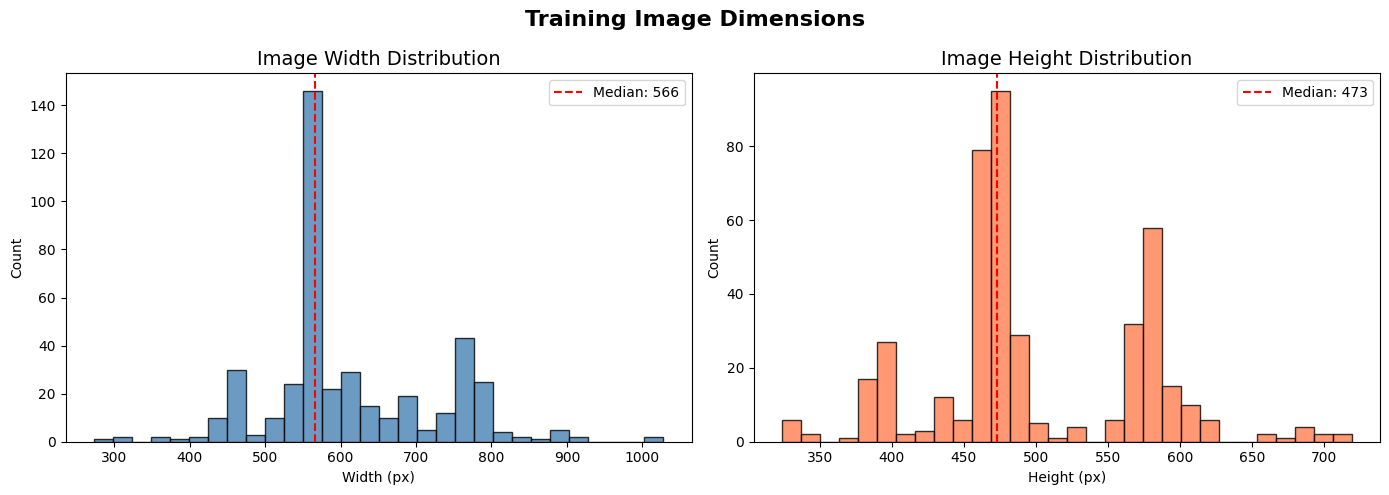

Width  — min: 273, max: 1028, mean: 612
Height — min: 324, max: 719, mean: 498


In [3]:
# Image Size Distribution 
widths, heights = [], []
sample_ids = train_csv['image_id'].values

for img_id in sample_ids:
    img_path = os.path.join(TRAIN_DIR, "images", img_id)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths, heights = np.array(widths), np.array(heights)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Image Width Distribution', fontsize=14)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Image Height Distribution', fontsize=14)
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
axes[1].legend()

plt.suptitle('Training Image Dimensions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Width  — min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.0f}")
print(f"Height — min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.0f}")


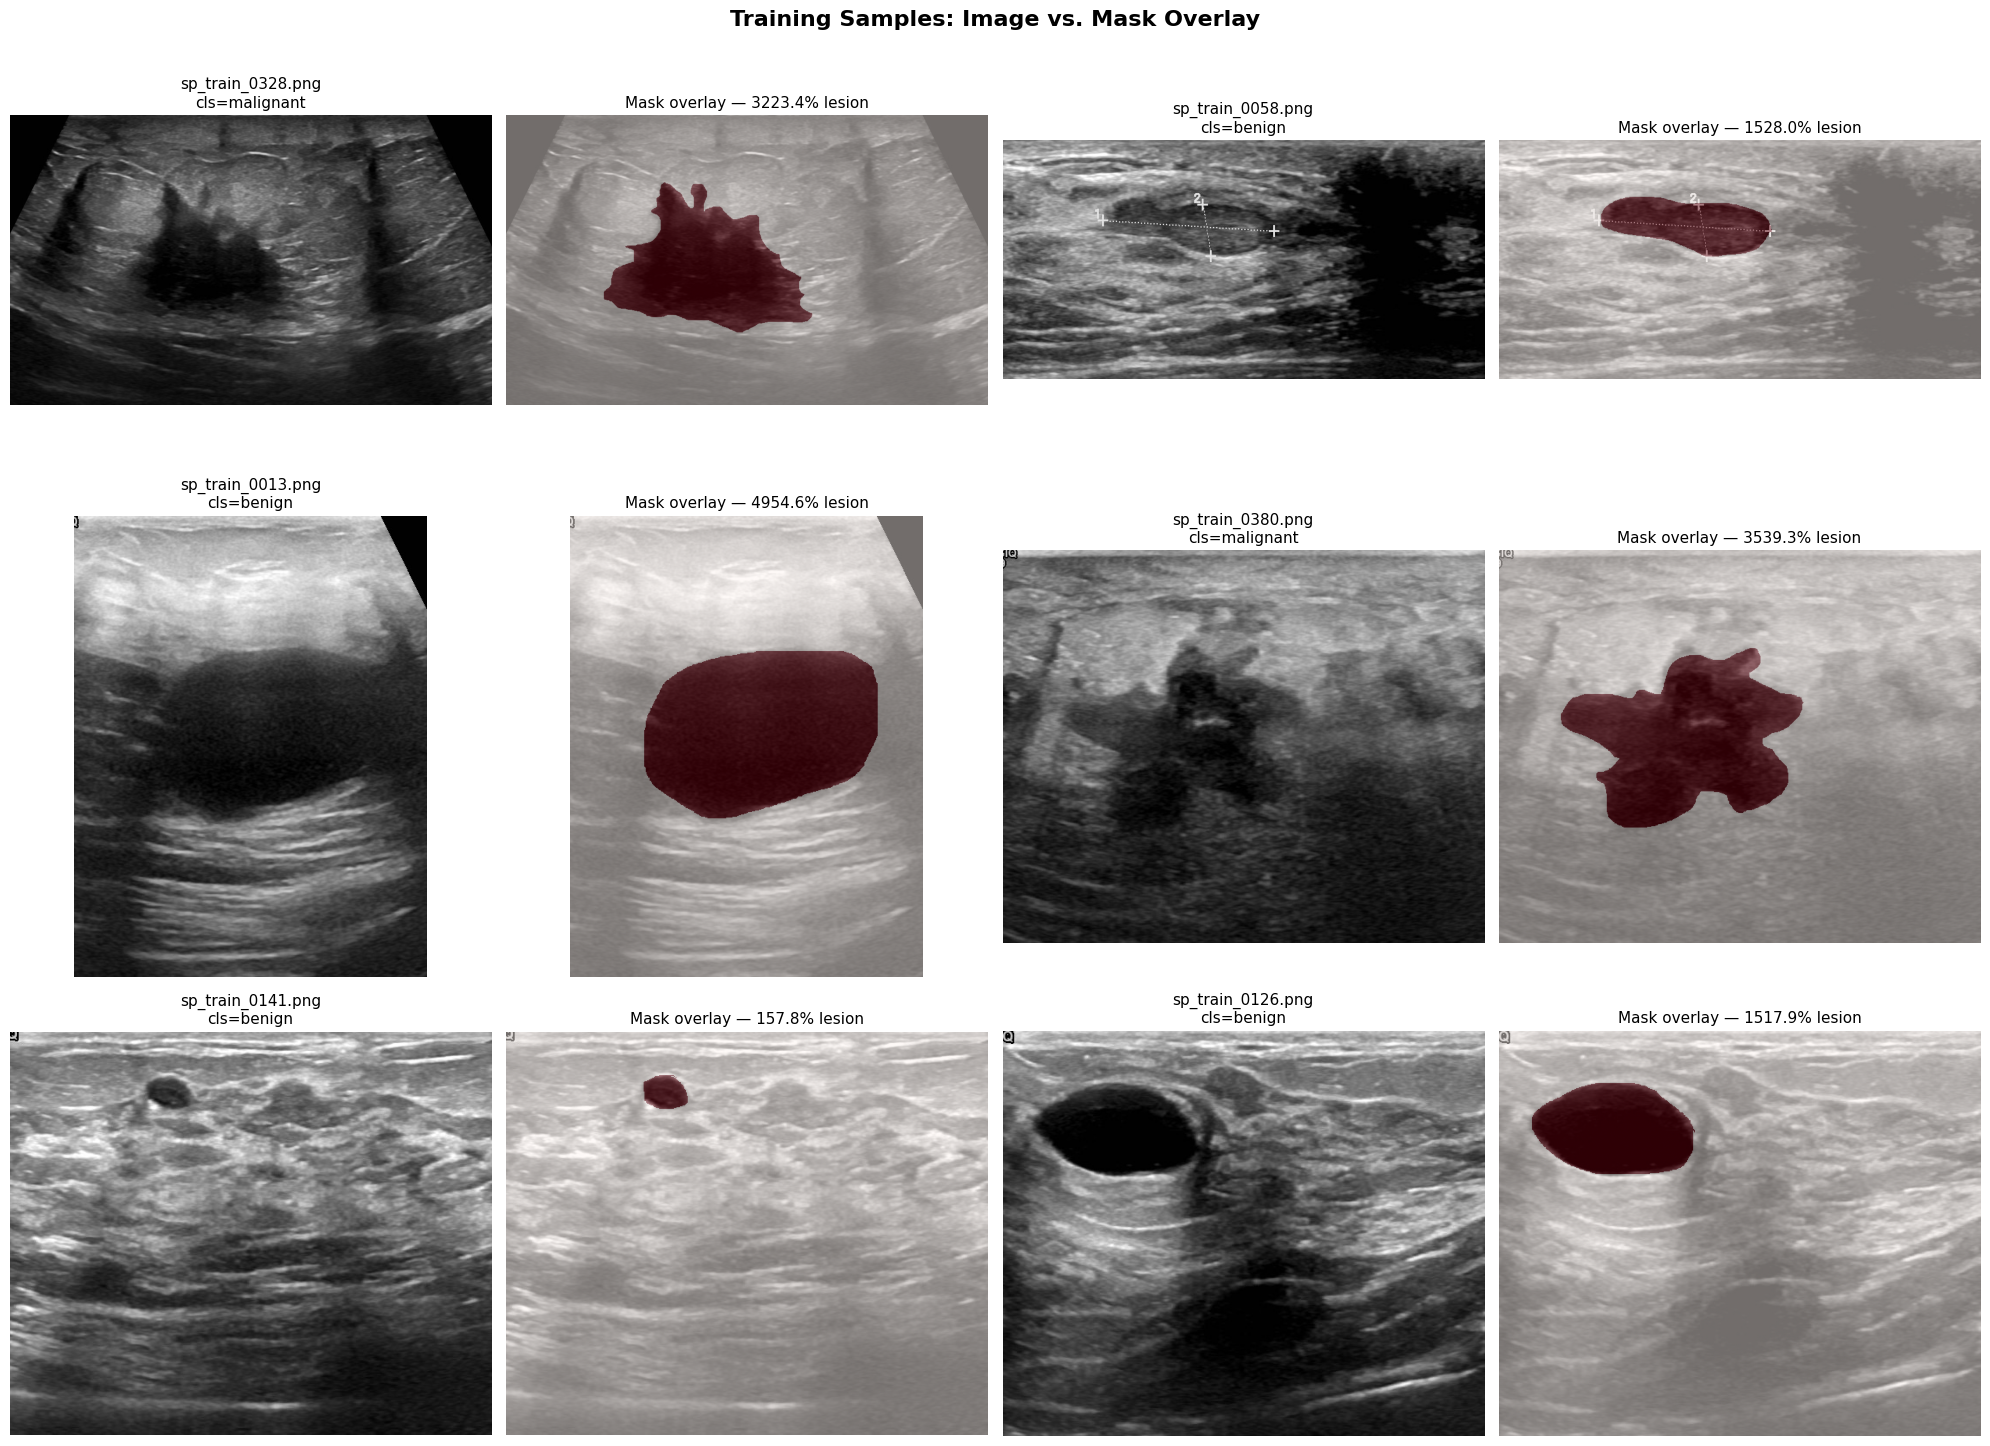

In [4]:
# Visualise Images with Mask Overlays
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
sample_indices = random.sample(range(len(train_csv)), 6)

for i, idx in enumerate(sample_indices):
    row = train_csv.iloc[idx]
    img_id = row['image_id']
    mask_id = img_id.replace('.png', '_mask.png')

    img  = np.array(Image.open(os.path.join(TRAIN_DIR, "images", img_id)))
    mask = np.array(Image.open(os.path.join(TRAIN_DIR, "masks", mask_id)).convert('L'))

    r, c = i // 2, (i % 2) * 2

    # Original image
    axes[r, c].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[r, c].set_title(f'{img_id}\ncls={row["cls"]}', fontsize=11)
    axes[r, c].axis('off')

    # Mask overlay
    axes[r, c+1].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[r, c+1].imshow(mask, cmap='Reds', alpha=0.45)
    axes[r, c+1].set_title(f'Mask overlay — {mask.sum()/(mask.shape[0]*mask.shape[1])*100:.1f}% lesion', fontsize=11)
    axes[r, c+1].axis('off')

plt.suptitle('Training Samples: Image vs. Mask Overlay', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


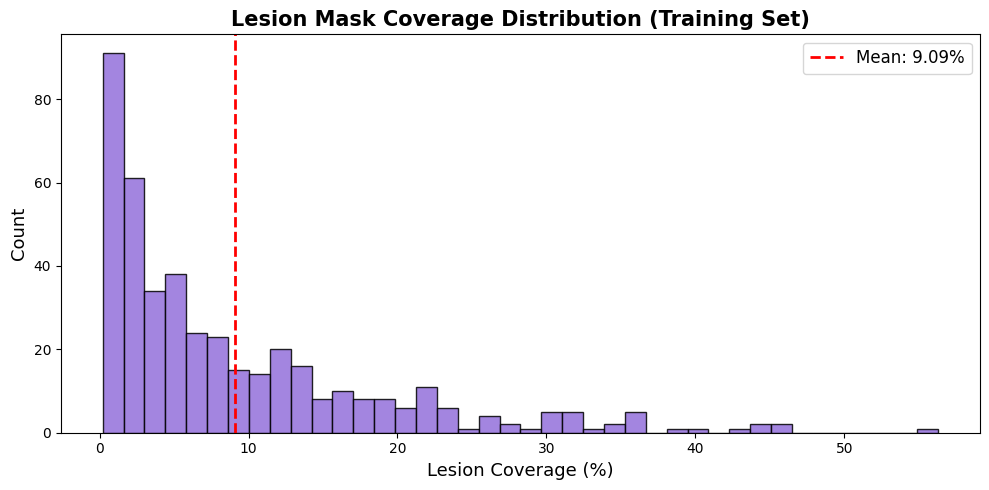

Mean lesion coverage: 9.09% | Median: 5.34% | Max: 56.29%


In [5]:
# Mask Coverage Statistics
coverages = []
for img_id in train_csv['image_id'].values:
    mask_id = img_id.replace('.png', '_mask.png')
    mask_path = os.path.join(TRAIN_DIR, "masks", mask_id)
    if os.path.exists(mask_path):
        mask = np.array(Image.open(mask_path).convert('L'))
        mask_binary = (mask > 127).astype(np.float32)
        coverages.append(mask_binary.sum() / mask_binary.size * 100)

coverages = np.array(coverages)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coverages, bins=40, color='mediumpurple', edgecolor='black', alpha=0.85)
ax.set_xlabel('Lesion Coverage (%)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Lesion Mask Coverage Distribution (Training Set)', fontsize=15, fontweight='bold')
ax.axvline(np.mean(coverages), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(coverages):.2f}%')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()
print(f"Mean lesion coverage: {np.mean(coverages):.2f}% | Median: {np.median(coverages):.2f}% | Max: {np.max(coverages):.2f}%")


# Image Loading & Augmentation

In [6]:
class JointTransform:
    """Apply segmentation-safe geometric ops + intensity augmentations."""

    def __init__(self, img_size=256, is_train=True):
        self.img_size = img_size
        self.is_train = is_train

    def __call__(self, image, mask):
        image = TF.resize(
            image,
            [self.img_size, self.img_size],
            interpolation=transforms.InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            [self.img_size, self.img_size],
            interpolation=transforms.InterpolationMode.NEAREST,
        )

        if self.is_train:
            # Horizontal flip only -- vertical flip is unnatural for ultrasound
            # orientation and was hurting convergence.
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Small rotation (anatomy-preserving).
            if random.random() < 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(
                    image,
                    angle,
                    interpolation=transforms.InterpolationMode.BILINEAR,
                )
                mask = TF.rotate(
                    mask,
                    angle,
                    interpolation=transforms.InterpolationMode.NEAREST,
                )


            if random.random() < 0.4:
                translate = [random.randint(-10, 10), random.randint(-10, 10)]
                scale = random.uniform(0.9, 1.1)
                image = TF.affine(
                    image,
                    angle=0,
                    translate=translate,
                    scale=scale,
                    shear=0,
                    interpolation=transforms.InterpolationMode.BILINEAR,
                )
                mask = TF.affine(
                    mask,
                    angle=0,
                    translate=translate,
                    scale=scale,
                    shear=0,
                    interpolation=transforms.InterpolationMode.NEAREST,
                )

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)

        if self.is_train:
            # Light intensity jitter to cover scanner variability.
            if random.random() < 0.5:
                image = TF.adjust_brightness(image, random.uniform(0.9, 1.1))
                image = TF.adjust_contrast(image, random.uniform(0.9, 1.1))

            # Low-variance Gaussian noise.
            if random.random() < 0.5:
                image = (image + torch.randn_like(image) * 0.015).clamp_(0.0, 1.0)

        mask = (mask > 0.5).float()
        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        return image, mask


class BreastLesionDataset(Dataset):
    """PyTorch dataset for breast ultrasound segmentation."""

    def __init__(self, csv_path, img_dir, mask_dir=None, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_ids = self.df["image_id"].tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_id)
        image = Image.open(img_path).convert("RGB")

        if self.mask_dir is not None:
            mask_id = img_id.replace(".png", "_mask.png")
            mask_path = os.path.join(self.mask_dir, mask_id)
            mask = Image.open(mask_path).convert("L")
        else:
            mask = Image.new("L", image.size, 0)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        return image, mask


print("Dataset & calm seg-safe augmentation defined (flip + small rotate/affine + light jitter).")


Dataset & calm seg-safe augmentation defined (flip + small rotate/affine + light jitter).


# DataLoader Initialisation

In [7]:
# ==============================================================================
# 4. DATALOADERS
# ==============================================================================
train_transform = JointTransform(img_size=IMG_SIZE, is_train=True)
val_transform   = JointTransform(img_size=IMG_SIZE, is_train=False)

train_dataset = BreastLesionDataset(
    csv_path  = os.path.join(TRAIN_DIR, "train.csv"),
    img_dir   = os.path.join(TRAIN_DIR, "images"),
    mask_dir  = os.path.join(TRAIN_DIR, "masks"),
    transform = train_transform
)

val_dataset = BreastLesionDataset(
    csv_path  = os.path.join(VAL_DIR, "val.csv"),
    img_dir   = os.path.join(VAL_DIR, "images"),
    mask_dir  = os.path.join(VAL_DIR, "masks"),
    transform = val_transform
)

test_dataset = BreastLesionDataset(
    csv_path  = os.path.join(TEST_DIR, "test.csv"),
    img_dir   = os.path.join(TEST_DIR, "images"),
    mask_dir  = None,           # no masks for test set
    transform = val_transform
)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=DATALOADER_PIN_MEMORY,
)
# persistent_workers is only valid when num_workers > 0. Setting it otherwise
# raises ValueError in torch>=2.0.
if NUM_WORKERS > 0 and DATALOADER_PERSISTENT_WORKERS:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=IS_TPU,           # static shapes per step on TPU
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=IS_TPU,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    **loader_kwargs,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Train images : {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")
print(
    f"DataLoader profile -> num_workers={NUM_WORKERS}, "
    f"pin_memory={DATALOADER_PIN_MEMORY}, persistent_workers={loader_kwargs.get('persistent_workers', False)}"
)


Train batches: 36 | Val batches: 8 | Test batches: 94
Train images : 427 | Val images: 90 | Test images: 94
DataLoader profile -> num_workers=2, pin_memory=False, persistent_workers=False


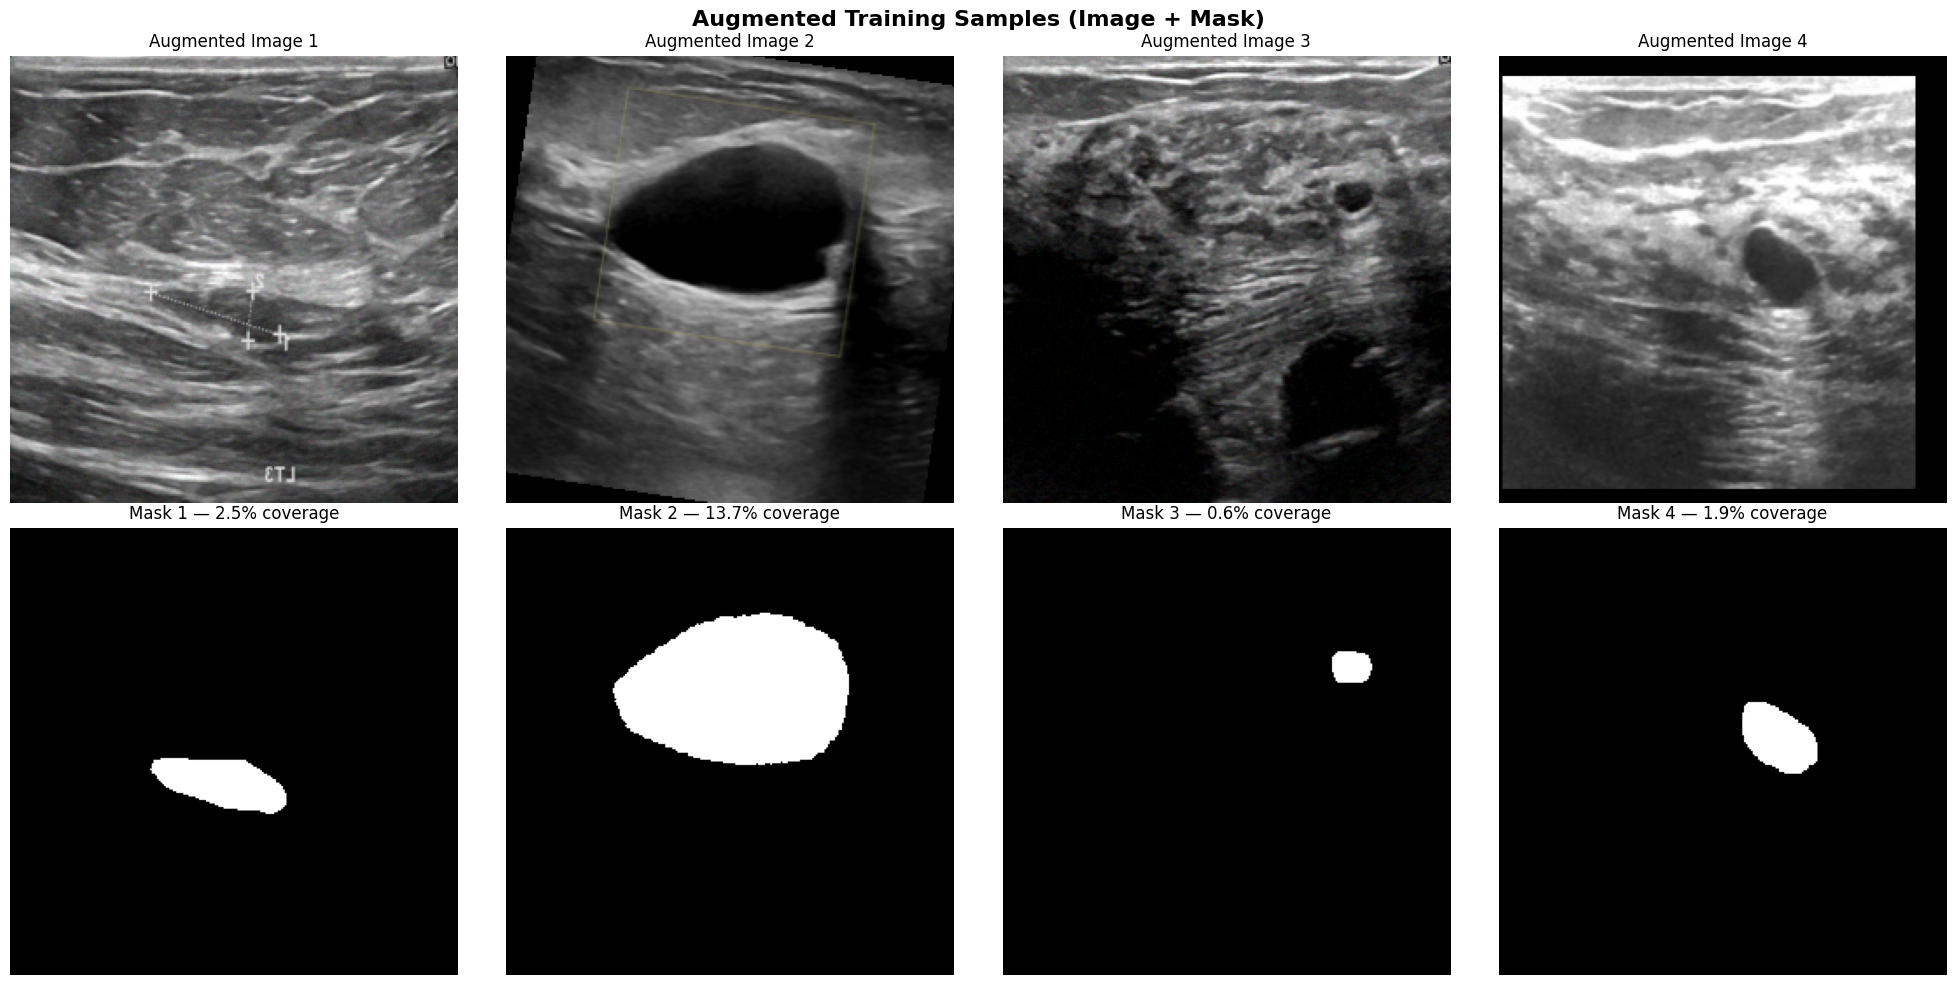

In [8]:
# Augmentation Sanity Check
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i in range(4):
    img, mask = train_dataset[i]
    # Un-normalise image for display
    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225])
    img_display = inv_norm(img).permute(1, 2, 0).clamp(0, 1).numpy()
    mask_display = mask.squeeze().numpy()

    axes[0, i].imshow(img_display)
    axes[0, i].set_title(f'Augmented Image {i+1}', fontsize=12)
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_display, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1} — {mask_display.sum()/mask_display.size*100:.1f}% coverage', fontsize=12)
    axes[1, i].axis('off')

plt.suptitle('Augmented Training Samples (Image + Mask)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Swin U-Net Architecture from Scratch

In [9]:
try:
    import timm  # noqa: F401
except ImportError:
    import subprocess
    print("[INFO] timm not found, installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm>=0.9.10"])
    import timm  # noqa: F401


# ── Window helpers ──────────────────────────────────────────────────────────
def _window_partition_2d(x, ws):
    """(B, H, W, C) -> (B*nW, ws*ws, C)."""
    b, h, w, c = x.shape
    x = x.view(b, h // ws, ws, w // ws, ws, c)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, ws * ws, c)


def _window_reverse_2d(windows, ws, h, w, b):
    """(B*nW, ws*ws, C) -> (B, H, W, C)."""
    x = windows.view(b, h // ws, w // ws, ws, ws, -1)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(b, h, w, -1)


class MLP(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.0):
        super().__init__()
        hidden_dim = hidden_dim or dim * 4
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.fc2(x))
        return x


class WindowAttention(nn.Module):
    """W-MSA with 2D relative position bias (for the scratch decoder)."""

    def __init__(self, dim, window_size=8, num_heads=4, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.rel_pos_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) ** 2, num_heads)
        )
        nn.init.trunc_normal_(self.rel_pos_bias_table, std=0.02)

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
        coords_flat = coords.flatten(1)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]
        rel = rel.permute(1, 2, 0).contiguous()
        rel[:, :, 0] += window_size - 1
        rel[:, :, 1] += window_size - 1
        rel[:, :, 0] *= 2 * window_size - 1
        self.register_buffer("rel_pos_index", rel.sum(-1), persistent=False)

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = (
            self.qkv(x)
            .reshape(B_, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = q * self.scale

        attn = q @ k.transpose(-2, -1)
        bias = self.rel_pos_bias_table[self.rel_pos_index.view(-1)].view(N, N, -1)
        attn = attn + bias.permute(2, 0, 1).contiguous().unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj_drop(self.proj(out))
        return out


class SwinBlock(nn.Module):
    """(S)W-MSA Swin block that operates on NCHW tensors."""

    def __init__(self, dim, num_heads, window_size=8, shift_size=0,
                 mlp_ratio=4.0, dropout=0.0, attn_drop=0.0):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads,
                                    attn_drop=attn_drop, proj_drop=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, hidden_dim=int(dim * mlp_ratio), dropout=dropout)
        self._attn_mask_cache = {}

    def _get_attn_mask(self, hp, wp, shift, device):
        if shift == 0:
            return None
        key = (hp, wp, str(device))
        cached = self._attn_mask_cache.get(key)
        if cached is not None:
            return cached
        ws = self.window_size
        img_mask = torch.zeros((1, hp, wp, 1), device=device)
        slices = (slice(0, -ws), slice(-ws, -shift), slice(-shift, None))
        cnt = 0
        for h_slice in slices:
            for w_slice in slices:
                img_mask[:, h_slice, w_slice, :] = cnt
                cnt += 1
        mask_windows = _window_partition_2d(img_mask, ws).view(-1, ws * ws)
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)
        self._attn_mask_cache[key] = attn_mask
        return attn_mask

    def forward(self, x):
        b, c, h, w = x.shape
        shortcut = x
        x = self.norm1(x.permute(0, 2, 3, 1).contiguous())

        pad_h = (self.window_size - h % self.window_size) % self.window_size
        pad_w = (self.window_size - w % self.window_size) % self.window_size
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h))
        _, hp, wp, _ = x.shape

        shift = self.shift_size if (hp > self.window_size and wp > self.window_size) else 0
        if shift > 0:
            x = torch.roll(x, shifts=(-shift, -shift), dims=(1, 2))
        attn_mask = self._get_attn_mask(hp, wp, shift, x.device)

        windows = _window_partition_2d(x, self.window_size)
        windows = self.attn(windows, mask=attn_mask)
        x = _window_reverse_2d(windows, self.window_size, hp, wp, b)

        if shift > 0:
            x = torch.roll(x, shifts=(shift, shift), dims=(1, 2))
        if pad_h > 0 or pad_w > 0:
            x = x[:, :h, :w, :].contiguous()

        x = x.permute(0, 3, 1, 2).contiguous()
        x = shortcut + x

        x_ffn = self.norm2(x.permute(0, 2, 3, 1).contiguous())
        x_ffn = self.mlp(x_ffn).permute(0, 3, 1, 2).contiguous()
        return x + x_ffn


class PatchExpand(nn.Module):
    """Inverse of PatchMerging: Linear(C -> 2C) then rearrange to 2x2 spatial (halves C)."""

    def __init__(self, in_dim):
        super().__init__()
        self.expand = nn.Linear(in_dim, 2 * in_dim, bias=False)
        self.norm = nn.LayerNorm(in_dim // 2)

    def forward(self, x):
        b, c, h, w = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = self.expand(x)
        x = x.view(b, h, w, 2, 2, c // 2)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
        x = x.view(b, h * 2, w * 2, c // 2)
        x = self.norm(x)
        return x.permute(0, 3, 1, 2).contiguous()


class SwinStage(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size=8, dropout=0.0, attn_drop=0.0):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinBlock(
                dim,
                num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                dropout=dropout,
                attn_drop=attn_drop,
            )
            for i in range(depth)
        ])

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return x


# Pretrained Swin-UNet

PRETRAINED_ENCODER_NAME = "swinv2_tiny_window8_256"


def _features_to_nchw(feat):
    """timm may return NHWC for Swin-family models; normalise to NCHW."""
    if feat.ndim != 4:
        return feat
    # Heuristic: in NHWC the last dim equals one of the expected channel sizes
    if feat.shape[1] in (96, 192, 384, 768) and feat.shape[-1] not in (96, 192, 384, 768):
        return feat
    if feat.shape[-1] in (96, 192, 384, 768):
        return feat.permute(0, 3, 1, 2).contiguous()
    return feat


class SwinUNet(nn.Module):
    """Pretrained SwinV2-Tiny encoder + from-scratch Swin decoder (U-shape)."""

    def __init__(self, out_channels=1, dropout=0.0, pretrained=True,
                 encoder_name=PRETRAINED_ENCODER_NAME):
        super().__init__()
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        dims = list(self.encoder.feature_info.channels())  # e.g. [96, 192, 384, 768]
        assert len(dims) == 4, f"Expected 4 feature stages, got {len(dims)}"
        c1, c2, c3, c4 = dims

        # Decoder -- each stage halves channels and doubles spatial size.
        self.up3 = PatchExpand(c4)
        self.fuse3 = nn.Conv2d(c4 // 2 + c3, c3, kernel_size=1)
        self.dec3 = SwinStage(c3, depth=2, num_heads=max(c3 // 32, 1),
                              window_size=SWIN_WINDOW_SIZE, dropout=dropout)

        self.up2 = PatchExpand(c3)
        self.fuse2 = nn.Conv2d(c3 // 2 + c2, c2, kernel_size=1)
        self.dec2 = SwinStage(c2, depth=2, num_heads=max(c2 // 32, 1),
                              window_size=SWIN_WINDOW_SIZE, dropout=dropout)

        self.up1 = PatchExpand(c2)
        self.fuse1 = nn.Conv2d(c2 // 2 + c1, c1, kernel_size=1)
        self.dec1 = SwinStage(c1, depth=2, num_heads=max(c1 // 32, 1),
                              window_size=SWIN_WINDOW_SIZE, dropout=dropout)

        # 4x upsample back to the original resolution (bilinear, artifact-free).
        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False),
            nn.Conv2d(c1, c1 // 2, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.out_conv = nn.Conv2d(c1 // 2, out_channels, kernel_size=1)

        self._encoder_dims = dims

    def encoder_parameters(self):
        return self.encoder.parameters()

    def decoder_parameters(self):
        for name, p in self.named_parameters():
            if not name.startswith("encoder."):
                yield p

    def forward(self, x):
        feats = self.encoder(x)
        feats = [_features_to_nchw(f) for f in feats]
        s1, s2, s3, bott = feats

        x = self.up3(bott)
        if x.shape[2:] != s3.shape[2:]:
            x = F.interpolate(x, size=s3.shape[2:], mode="bilinear", align_corners=False)
        x = self.fuse3(torch.cat([x, s3], dim=1))
        x = self.dec3(x)

        x = self.up2(x)
        if x.shape[2:] != s2.shape[2:]:
            x = F.interpolate(x, size=s2.shape[2:], mode="bilinear", align_corners=False)
        x = self.fuse2(torch.cat([x, s2], dim=1))
        x = self.dec2(x)

        x = self.up1(x)
        if x.shape[2:] != s1.shape[2:]:
            x = F.interpolate(x, size=s1.shape[2:], mode="bilinear", align_corners=False)
        x = self.fuse1(torch.cat([x, s1], dim=1))
        x = self.dec1(x)

        x = self.final_up(x)
        return self.out_conv(x)


def init_decoder_weights(module):
    """Only the DECODER gets Kaiming/trunc init -- the encoder is already
    initialised (pretrained) and we must not overwrite its weights."""
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.trunc_normal_(module.weight, std=0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0)
    elif isinstance(module, nn.LayerNorm):
        if module.weight is not None:
            nn.init.constant_(module.weight, 1)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0)


model = SwinUNet(out_channels=1, dropout=SWIN_DROPOUT, pretrained=True)

# Initialise ONLY the decoder -- leave the pretrained encoder untouched.
for name, sub in model.named_children():
    if name == "encoder":
        continue
    sub.apply(init_decoder_weights)

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = total_params - enc_params
print(f"[INFO] Swin-UNet (pretrained encoder: {PRETRAINED_ENCODER_NAME}) on {DEVICE}")
print(f"[INFO] Encoder dims     : {model._encoder_dims}")
print(f"[INFO] Encoder params   : {enc_params:,}  (pretrained, fine-tuned with low LR)")
print(f"[INFO] Decoder params   : {dec_params:,}  (from scratch)")
print(f"[INFO] Total params     : {total_params:,}")

model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = model(dummy)
    if IS_TPU:
        xm.mark_step()
print(f"[INFO] Input shape : {tuple(dummy.shape)}")
print(f"[INFO] Output shape: {tuple(out.shape)}")
assert tuple(out.shape) == (2, 1, IMG_SIZE, IMG_SIZE), "Output shape mismatch!"
print("[INFO] Shape test passed")


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

[INFO] Swin-UNet (pretrained encoder: swinv2_tiny_window8_256) on cpu
[INFO] Encoder dims     : [96, 192, 384, 768]
[INFO] Encoder params   : 27,576,618  (pretrained, fine-tuned with low LR)
[INFO] Decoder params   : 6,650,731  (from scratch)
[INFO] Total params     : 34,227,349
[INFO] Input shape : (2, 3, 256, 256)
[INFO] Output shape: (2, 1, 256, 256)
[INFO] Shape test passed


# Loss Functions & Metrics

In [10]:
# ==============================================================================
# 6. LOSS FUNCTIONS & SOTA-STYLE METRICS
#
# On small, imbalanced segmentation datasets the most reliable loss is simply
# BCE (with a positive-class weight to counter the pixel imbalance) + soft
# Dice. Focal Tversky helps in specific settings but adds gradient noise that
# hurts a from-scratch transformer on tiny data -- we drop it here.
# ==============================================================================


class DiceLoss(nn.Module):
    """Soft Dice loss, computed per-sample then averaged."""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)
        inter = (probs * targets).sum(dim=1)
        denom = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2 * inter + self.smooth) / (denom + self.smooth)
        return (1 - dice).mean()


def _estimate_pos_weight(csv_path, mask_dir, img_size=256, max_samples=128):
    """Estimate BCE pos_weight ~= (#neg pixels) / (#pos pixels) from the train set.

    Lesions occupy ~2-10% of a breast-ultrasound frame, so a pos_weight of
    roughly 10-40 keeps BCE from being dominated by the background.
    """
    df = pd.read_csv(csv_path)
    ids = df["image_id"].tolist()
    random.Random(0).shuffle(ids)
    ids = ids[:max_samples]

    pos, total = 0.0, 0.0
    for img_id in ids:
        mask_id = img_id.replace(".png", "_mask.png")
        mask_path = os.path.join(mask_dir, mask_id)
        if not os.path.exists(mask_path):
            continue
        m = Image.open(mask_path).convert("L").resize(
            (img_size, img_size), Image.NEAREST
        )
        arr = (np.asarray(m) > 127).astype(np.float32)
        pos += float(arr.sum())
        total += float(arr.size)

    if pos <= 0:
        return 1.0
    neg = total - pos
    w = neg / max(pos, 1.0)
    # Clamp to a sane range -- unbounded pos_weight destabilises BCE.
    return float(np.clip(w, 1.0, 40.0))


class BCEDiceLoss(nn.Module):
    """pos-weighted BCE-with-logits + soft Dice.

    Weights favour Dice because the eval metric is Dice; BCE is kept as a
    stabiliser and to give dense pixel-level gradient in the early epochs.
    """

    def __init__(self, pos_weight=1.0, bce_weight=0.4, dice_weight=0.6):
        super().__init__()
        self.register_buffer("pos_weight", torch.tensor(float(pos_weight)))
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        # Recreate BCE each call so the pos_weight buffer follows the module
        # device. This avoids a CPU/GPU mismatch when the module is moved.
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight.to(logits.device)
        )
        return self.bce_weight * bce + self.dice_weight * self.dice(logits, targets)


def _confusion_counts(logits, targets, threshold=0.5):
    """Per-sample TP/TN/FP/FN counts -> averaged metrics match each image."""
    preds = (torch.sigmoid(logits) > threshold).float()
    preds = preds.reshape(preds.size(0), -1)
    targets = targets.reshape(targets.size(0), -1)
    tp = (preds * targets).sum(dim=1)
    tn = ((1 - preds) * (1 - targets)).sum(dim=1)
    fp = (preds * (1 - targets)).sum(dim=1)
    fn = ((1 - preds) * targets).sum(dim=1)
    return tp, tn, fp, fn


def dice_coefficient(logits, targets, threshold=0.5, smooth=1e-6):
    tp, _, fp, fn = _confusion_counts(logits, targets, threshold)
    return ((2 * tp + smooth) / (2 * tp + fp + fn + smooth)).mean()


def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    tp, _, fp, fn = _confusion_counts(logits, targets, threshold)
    return ((tp + smooth) / (tp + fp + fn + smooth)).mean()


def precision_score(logits, targets, threshold=0.5, smooth=1e-6):
    tp, _, fp, _ = _confusion_counts(logits, targets, threshold)
    return ((tp + smooth) / (tp + fp + smooth)).mean()


def recall_score(logits, targets, threshold=0.5, smooth=1e-6):
    tp, _, _, fn = _confusion_counts(logits, targets, threshold)
    return ((tp + smooth) / (tp + fn + smooth)).mean()


def f1_score(logits, targets, threshold=0.5, smooth=1e-6):
    tp, _, fp, fn = _confusion_counts(logits, targets, threshold)
    return ((2 * tp + smooth) / (2 * tp + fp + fn + smooth)).mean()


def specificity_score(logits, targets, threshold=0.5, smooth=1e-6):
    _, tn, fp, _ = _confusion_counts(logits, targets, threshold)
    return ((tn + smooth) / (tn + fp + smooth)).mean()


def balanced_accuracy(logits, targets, threshold=0.5, smooth=1e-6):
    tp, tn, fp, fn = _confusion_counts(logits, targets, threshold)
    sens = (tp + smooth) / (tp + fn + smooth)
    spec = (tn + smooth) / (tn + fp + smooth)
    return (0.5 * (sens + spec)).mean()


def metric_suite(logits, targets, threshold=0.5):
    return {
        "dice": dice_coefficient(logits, targets, threshold),
        "iou": iou_score(logits, targets, threshold),
        "precision": precision_score(logits, targets, threshold),
        "recall": recall_score(logits, targets, threshold),
        "f1": f1_score(logits, targets, threshold),
        "specificity": specificity_score(logits, targets, threshold),
        "balanced_acc": balanced_accuracy(logits, targets, threshold),
    }


_pos_weight = _estimate_pos_weight(
    os.path.join(TRAIN_DIR, "train.csv"),
    os.path.join(TRAIN_DIR, "masks"),
    img_size=IMG_SIZE,
)
criterion = BCEDiceLoss(pos_weight=_pos_weight, bce_weight=0.4, dice_weight=0.6).to(DEVICE)
print(f"[INFO] Loss = 0.4*BCE(pos_weight={_pos_weight:.2f}) + 0.6*Dice")
print("[INFO] Tracking metrics: Dice, IoU, Precision, Recall, F1, Specificity, Balanced Accuracy")


[INFO] Loss = 0.4*BCE(pos_weight=10.49) + 0.6*Dice
[INFO] Tracking metrics: Dice, IoU, Precision, Recall, F1, Specificity, Balanced Accuracy


# Training Loop (Seth) & Validation Monitoring

In [11]:
import time

ENCODER_LR_FACTOR = 0.1

optimizer = torch.optim.AdamW(
    [
        {"params": list(model.encoder_parameters()), "lr": LEARNING_RATE * ENCODER_LR_FACTOR},
        {"params": list(model.decoder_parameters()), "lr": LEARNING_RATE},
    ],
    weight_decay=WEIGHT_DECAY,
)

# Linear-warmup -> cosine decay schedule, per-step. Each param group keeps its
# own base LR; the scheduler scales both by the same multiplier each step.
steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(int(0.10 * total_steps), 150)
min_lr_ratio = 1e-6 / max(LEARNING_RATE, 1e-9)


def _lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    prog = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    prog = min(1.0, max(0.0, prog))
    return min_lr_ratio + (1 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * prog))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=[_lr_lambda, _lr_lambda])

# CUDA AMP for ~2x training speed-up on GPU. TPU/CPU run in fp32.
USE_AMP = (not IS_TPU) and torch.cuda.is_available()
amp_scaler = torch.amp.GradScaler() if USE_AMP else None

metric_names = ["dice", "iou", "precision", "recall", "f1", "specificity", "balanced_acc"]
history = {"train_loss": [], "val_loss": []}
for m in metric_names:
    history[f"train_{m}"] = []
    history[f"val_{m}"] = []

best_val_dice = 0.0
epochs_no_improve = 0
global_step = 0


def run_epoch(loader, is_train=True, max_batches=None):
    global global_step
    model.train(is_train)

    loss_sum = 0.0
    metric_sums = {k: 0.0 for k in metric_names}
    n_steps = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch_idx, (images, masks) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(DEVICE, non_blocking=DATALOADER_PIN_MEMORY)
            masks = masks.to(DEVICE, non_blocking=DATALOADER_PIN_MEMORY)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            if is_train and USE_AMP:
                with torch.cuda.amp.autocast():
                    logits = model(images)
                    loss = criterion(logits, masks)
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                amp_scaler.step(optimizer)
                amp_scaler.update()
                scheduler.step()
                global_step += 1
            else:
                logits = model(images)
                loss = criterion(logits, masks)
                if is_train:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                    if IS_TPU:
                        xm.optimizer_step(optimizer)
                    else:
                        optimizer.step()
                    scheduler.step()
                    global_step += 1

            with torch.no_grad():
                batch_metrics = metric_suite(logits.detach().float(), masks)
            loss_sum += float(loss.item())
            for k, v in batch_metrics.items():
                metric_sums[k] += float(v.item())
            n_steps += 1

            if IS_TPU:
                xm.mark_step()

    denom = max(n_steps, 1)
    return loss_sum / denom, {k: metric_sums[k] / denom for k in metric_names}


# --- Smoke test -------------------------------------------------------------
if RUN_SMOKE_TEST:
    print("=" * 80)
    print("[INFO] Starting TPU/GPU smoke test before full training")
    print(
        f"[INFO] Smoke settings -> epochs={SMOKE_TEST_EPOCHS}, "
        f"train_batches={SMOKE_MAX_TRAIN_BATCHES}, val_batches={SMOKE_MAX_VAL_BATCHES}"
    )
    for smoke_epoch in range(SMOKE_TEST_EPOCHS):
        t0 = time.time()
        sm_train_loss, sm_train_metrics = run_epoch(
            train_loader, is_train=True, max_batches=SMOKE_MAX_TRAIN_BATCHES,
        )
        sm_val_loss, sm_val_metrics = run_epoch(
            val_loader, is_train=False, max_batches=SMOKE_MAX_VAL_BATCHES,
        )
        dt = time.time() - t0
        print(
            f"Smoke Epoch [{smoke_epoch + 1}/{SMOKE_TEST_EPOCHS}] | "
            f"Train Loss: {sm_train_loss:.4f} Dice: {sm_train_metrics['dice']:.4f} | "
            f"Val Loss: {sm_val_loss:.4f} Dice: {sm_val_metrics['dice']:.4f} | "
            f"{dt:.1f}s"
        )
    print("[INFO] Smoke test complete. Proceeding to full training...")

    # Reset LR state so warmup starts cleanly for the real run.
    global_step = 0
    for g, base in zip(
        optimizer.param_groups,
        [LEARNING_RATE * ENCODER_LR_FACTOR, LEARNING_RATE],
    ):
        g["lr"] = 0.0
        g["initial_lr"] = base
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=[_lr_lambda, _lr_lambda])


# --- Full training
print("=" * 80)
print(f"[INFO] Starting full training - {EPOCHS} epochs, early-stop patience={PATIENCE}")
print(
    f"[INFO] LR schedule -> {warmup_steps} warmup / {total_steps} total steps | "
    f"enc_lr={LEARNING_RATE * ENCODER_LR_FACTOR:.2e}, dec_lr={LEARNING_RATE:.2e}"
)

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_metrics = run_epoch(train_loader, is_train=True)
    val_loss, val_metrics = run_epoch(val_loader, is_train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    for m in metric_names:
        history[f"train_{m}"].append(train_metrics[m])
        history[f"val_{m}"].append(val_metrics[m])

    lrs_now = [g["lr"] for g in optimizer.param_groups]
    dt = time.time() - t0

    print(
        f"Epoch [{epoch + 1:03d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} Dice: {train_metrics['dice']:.4f} IoU: {train_metrics['iou']:.4f} F1: {train_metrics['f1']:.4f} | "
        f"Val Loss: {val_loss:.4f} Dice: {val_metrics['dice']:.4f} IoU: {val_metrics['iou']:.4f} F1: {val_metrics['f1']:.4f} | "
        f"LR: enc={lrs_now[0]:.2e} dec={lrs_now[1]:.2e} | {dt:.1f}s"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        save_best_checkpoint(model, BEST_MODEL_PATH)
        print(f"   >>> Best model saved to {BEST_MODEL_PATH} (Val Dice: {best_val_dice:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"[INFO] Early stopping at epoch {epoch + 1} (no improvement for {PATIENCE} epochs)")
            break

print("=" * 80)
print(f"[INFO] Training complete. Best Val Dice: {best_val_dice:.4f}")


[INFO] Starting TPU/GPU smoke test before full training
[INFO] Smoke settings -> epochs=2, train_batches=8, val_batches=4
Smoke Epoch [1/2] | Train Loss: 1.0356 Dice: 0.1600 | Val Loss: 0.9792 Dice: 0.1084 | 82.4s
Smoke Epoch [2/2] | Train Loss: 1.0115 Dice: 0.1409 | Val Loss: 0.9790 Dice: 0.1111 | 86.5s
[INFO] Smoke test complete. Proceeding to full training...
[INFO] Starting full training - 200 epochs, early-stop patience=10
[INFO] LR schedule -> 720 warmup / 7200 total steps | enc_lr=3.00e-05, dec_lr=3.00e-04
Epoch [001/200] | Train Loss: 1.0335 Dice: 0.1632 IoU: 0.0973 F1: 0.1632 | Val Loss: 1.0531 Dice: 0.2029 IoU: 0.1241 F1: 0.2029 | LR: enc=1.50e-06 dec=1.50e-05 | 322.8s
   >>> Best model saved to /kaggle/working/best_unet.pth (Val Dice: 0.2029)
Epoch [002/200] | Train Loss: 1.0038 Dice: 0.3349 IoU: 0.2274 F1: 0.3349 | Val Loss: 0.9561 Dice: 0.5208 IoU: 0.3879 F1: 0.5208 | LR: enc=3.00e-06 dec=3.00e-05 | 324.6s
   >>> Best model saved to /kaggle/working/best_unet.pth (Val Dice:

# Training Curves


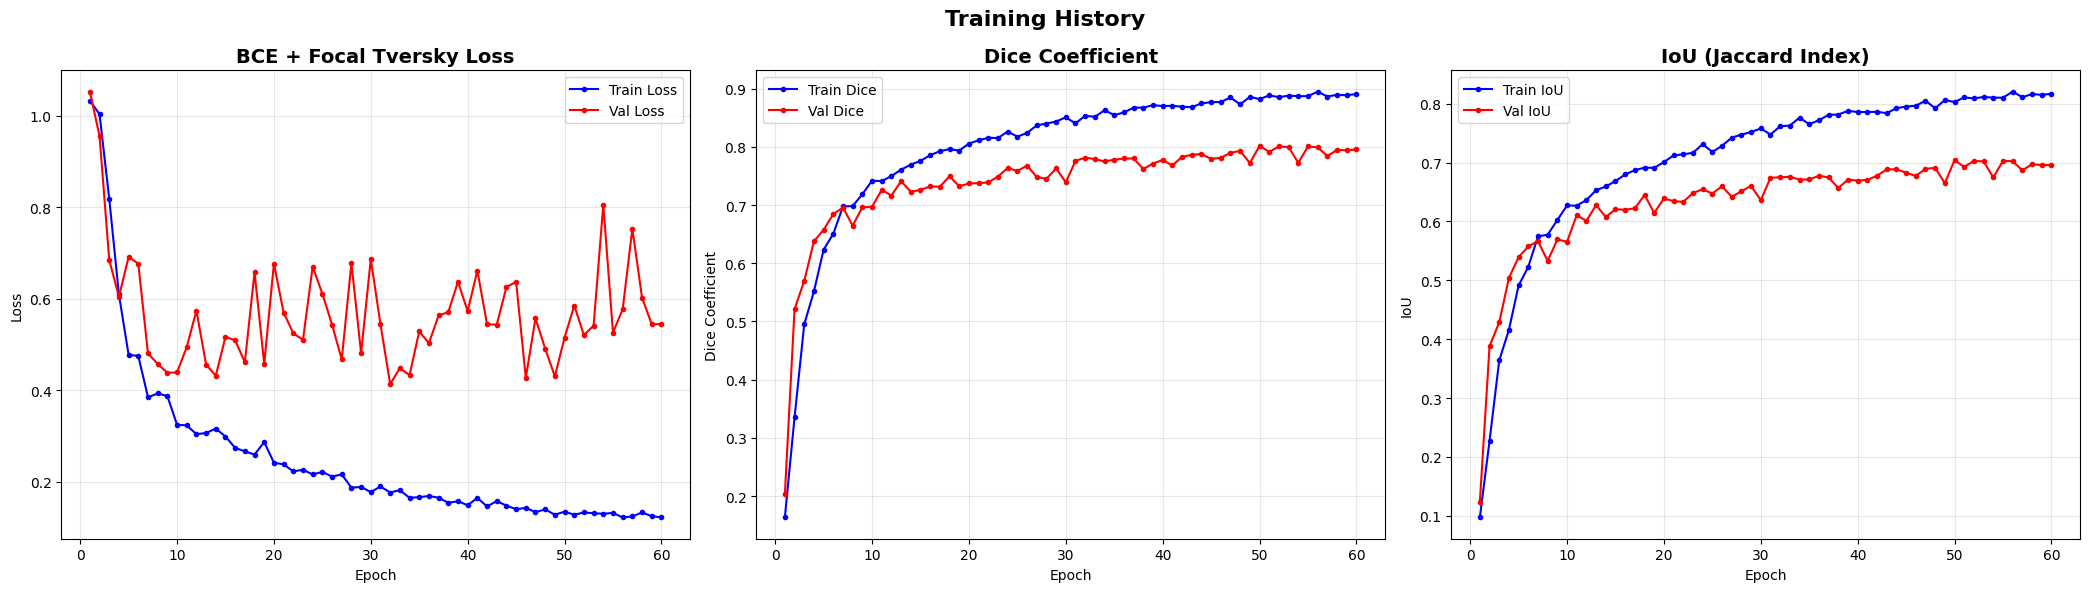

In [12]:
# TRAINING CURVES
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

epochs_ran = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history["train_loss"], "b-o", markersize=3, label="Train Loss")
axes[0].plot(epochs_ran, history["val_loss"], "r-o", markersize=3, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("BCE + Focal Tversky Loss", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice
axes[1].plot(epochs_ran, history["train_dice"], "b-o", markersize=3, label="Train Dice")
axes[1].plot(epochs_ran, history["val_dice"], "r-o", markersize=3, label="Val Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Coefficient")
axes[1].set_title("Dice Coefficient", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(epochs_ran, history["train_iou"], "b-o", markersize=3, label="Train IoU")
axes[2].plot(epochs_ran, history["val_iou"], "r-o", markersize=3, label="Val IoU")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].set_title("IoU (Jaccard Index)", fontsize=14, fontweight="bold")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


# Evaluation on the Validation Set Using Dice


In [13]:
# SAFE EVALUATION SCRIPT
import torch

print("[INFO] Attempting to safely load TPU-trained weights...")

state_dict = torch.load(BEST_MODEL_PATH, map_location=torch.device("cpu"), weights_only=False)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

print(f"[INFO] Weights successfully loaded and dispatched to {DEVICE}")

val_loss_sum = 0.0
metric_sums = {k: 0.0 for k in ["dice", "iou", "precision", "recall", "f1", "specificity", "balanced_acc"]}

per_image_dice = []
per_image_iou = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        loss = criterion(logits, masks)

        val_loss_sum += loss.item()
        batch_metrics = metric_suite(logits, masks)
        for k, v in batch_metrics.items():
            metric_sums[k] += v.item()

        for i in range(images.size(0)):
            d = dice_coefficient(logits[i:i + 1], masks[i:i + 1]).item()
            iou = iou_score(logits[i:i + 1], masks[i:i + 1]).item()
            per_image_dice.append(d)
            per_image_iou.append(iou)

per_image_dice = np.array(per_image_dice)
per_image_iou = np.array(per_image_iou)

n_val = len(val_loader)
val_loss_final = val_loss_sum / n_val
val_metrics_final = {k: metric_sums[k] / n_val for k in metric_sums}

print("=== FINAL RE-EVALUATION ===")
print(f"Validation Loss        : {val_loss_final:.4f}")
print(f"Validation Dice        : {val_metrics_final['dice']:.4f}")
print(f"Validation IoU         : {val_metrics_final['iou']:.4f}")
print(f"Validation Precision   : {val_metrics_final['precision']:.4f}")
print(f"Validation Recall      : {val_metrics_final['recall']:.4f}")
print(f"Validation F1          : {val_metrics_final['f1']:.4f}")
print(f"Validation Specificity : {val_metrics_final['specificity']:.4f}")
print(f"Validation Bal. Acc    : {val_metrics_final['balanced_acc']:.4f}")


[INFO] Attempting to safely load TPU-trained weights...
[INFO] Weights successfully loaded and dispatched to cpu
=== FINAL RE-EVALUATION ===
Validation Loss        : 0.5154
Validation Dice        : 0.8017
Validation IoU         : 0.7041
Validation Precision   : 0.8157
Validation Recall      : 0.8428
Validation F1          : 0.8017
Validation Specificity : 0.9672
Validation Bal. Acc    : 0.9050


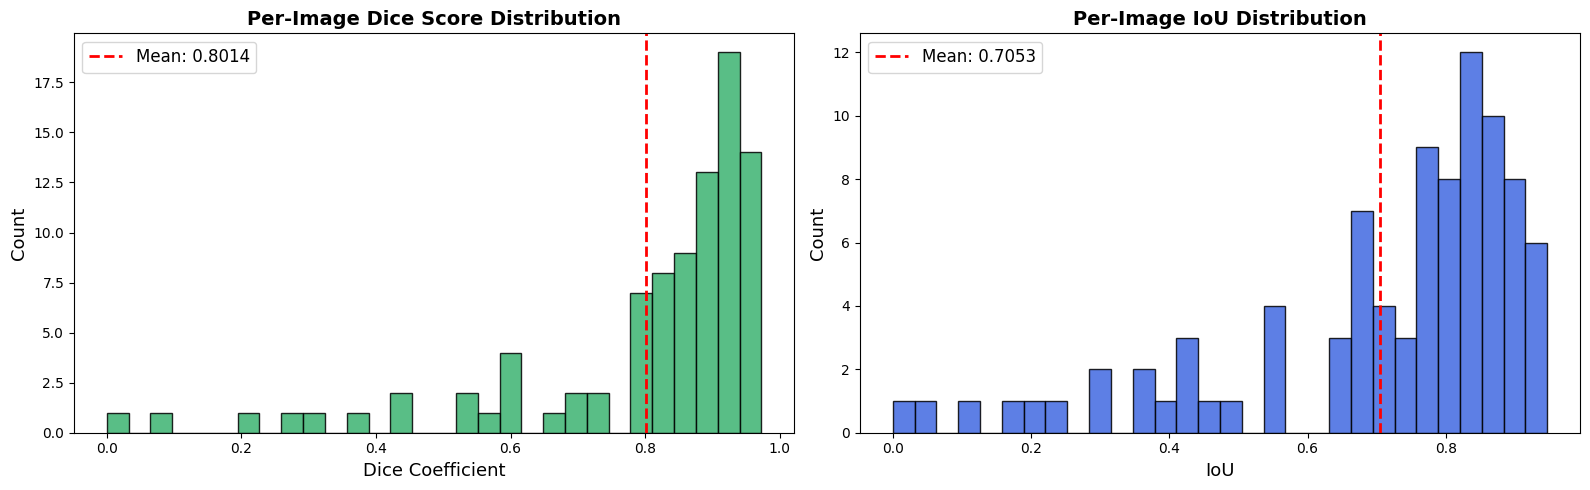

In [14]:
# Dice Score Distribution 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_image_dice, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0].axvline(per_image_dice.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {per_image_dice.mean():.4f}')
axes[0].set_xlabel('Dice Coefficient', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Per-Image Dice Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)

axes[1].hist(per_image_iou, bins=30, color='royalblue', edgecolor='black', alpha=0.85)
axes[1].axvline(per_image_iou.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {per_image_iou.mean():.4f}')
axes[1].set_xlabel('IoU', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Per-Image IoU Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


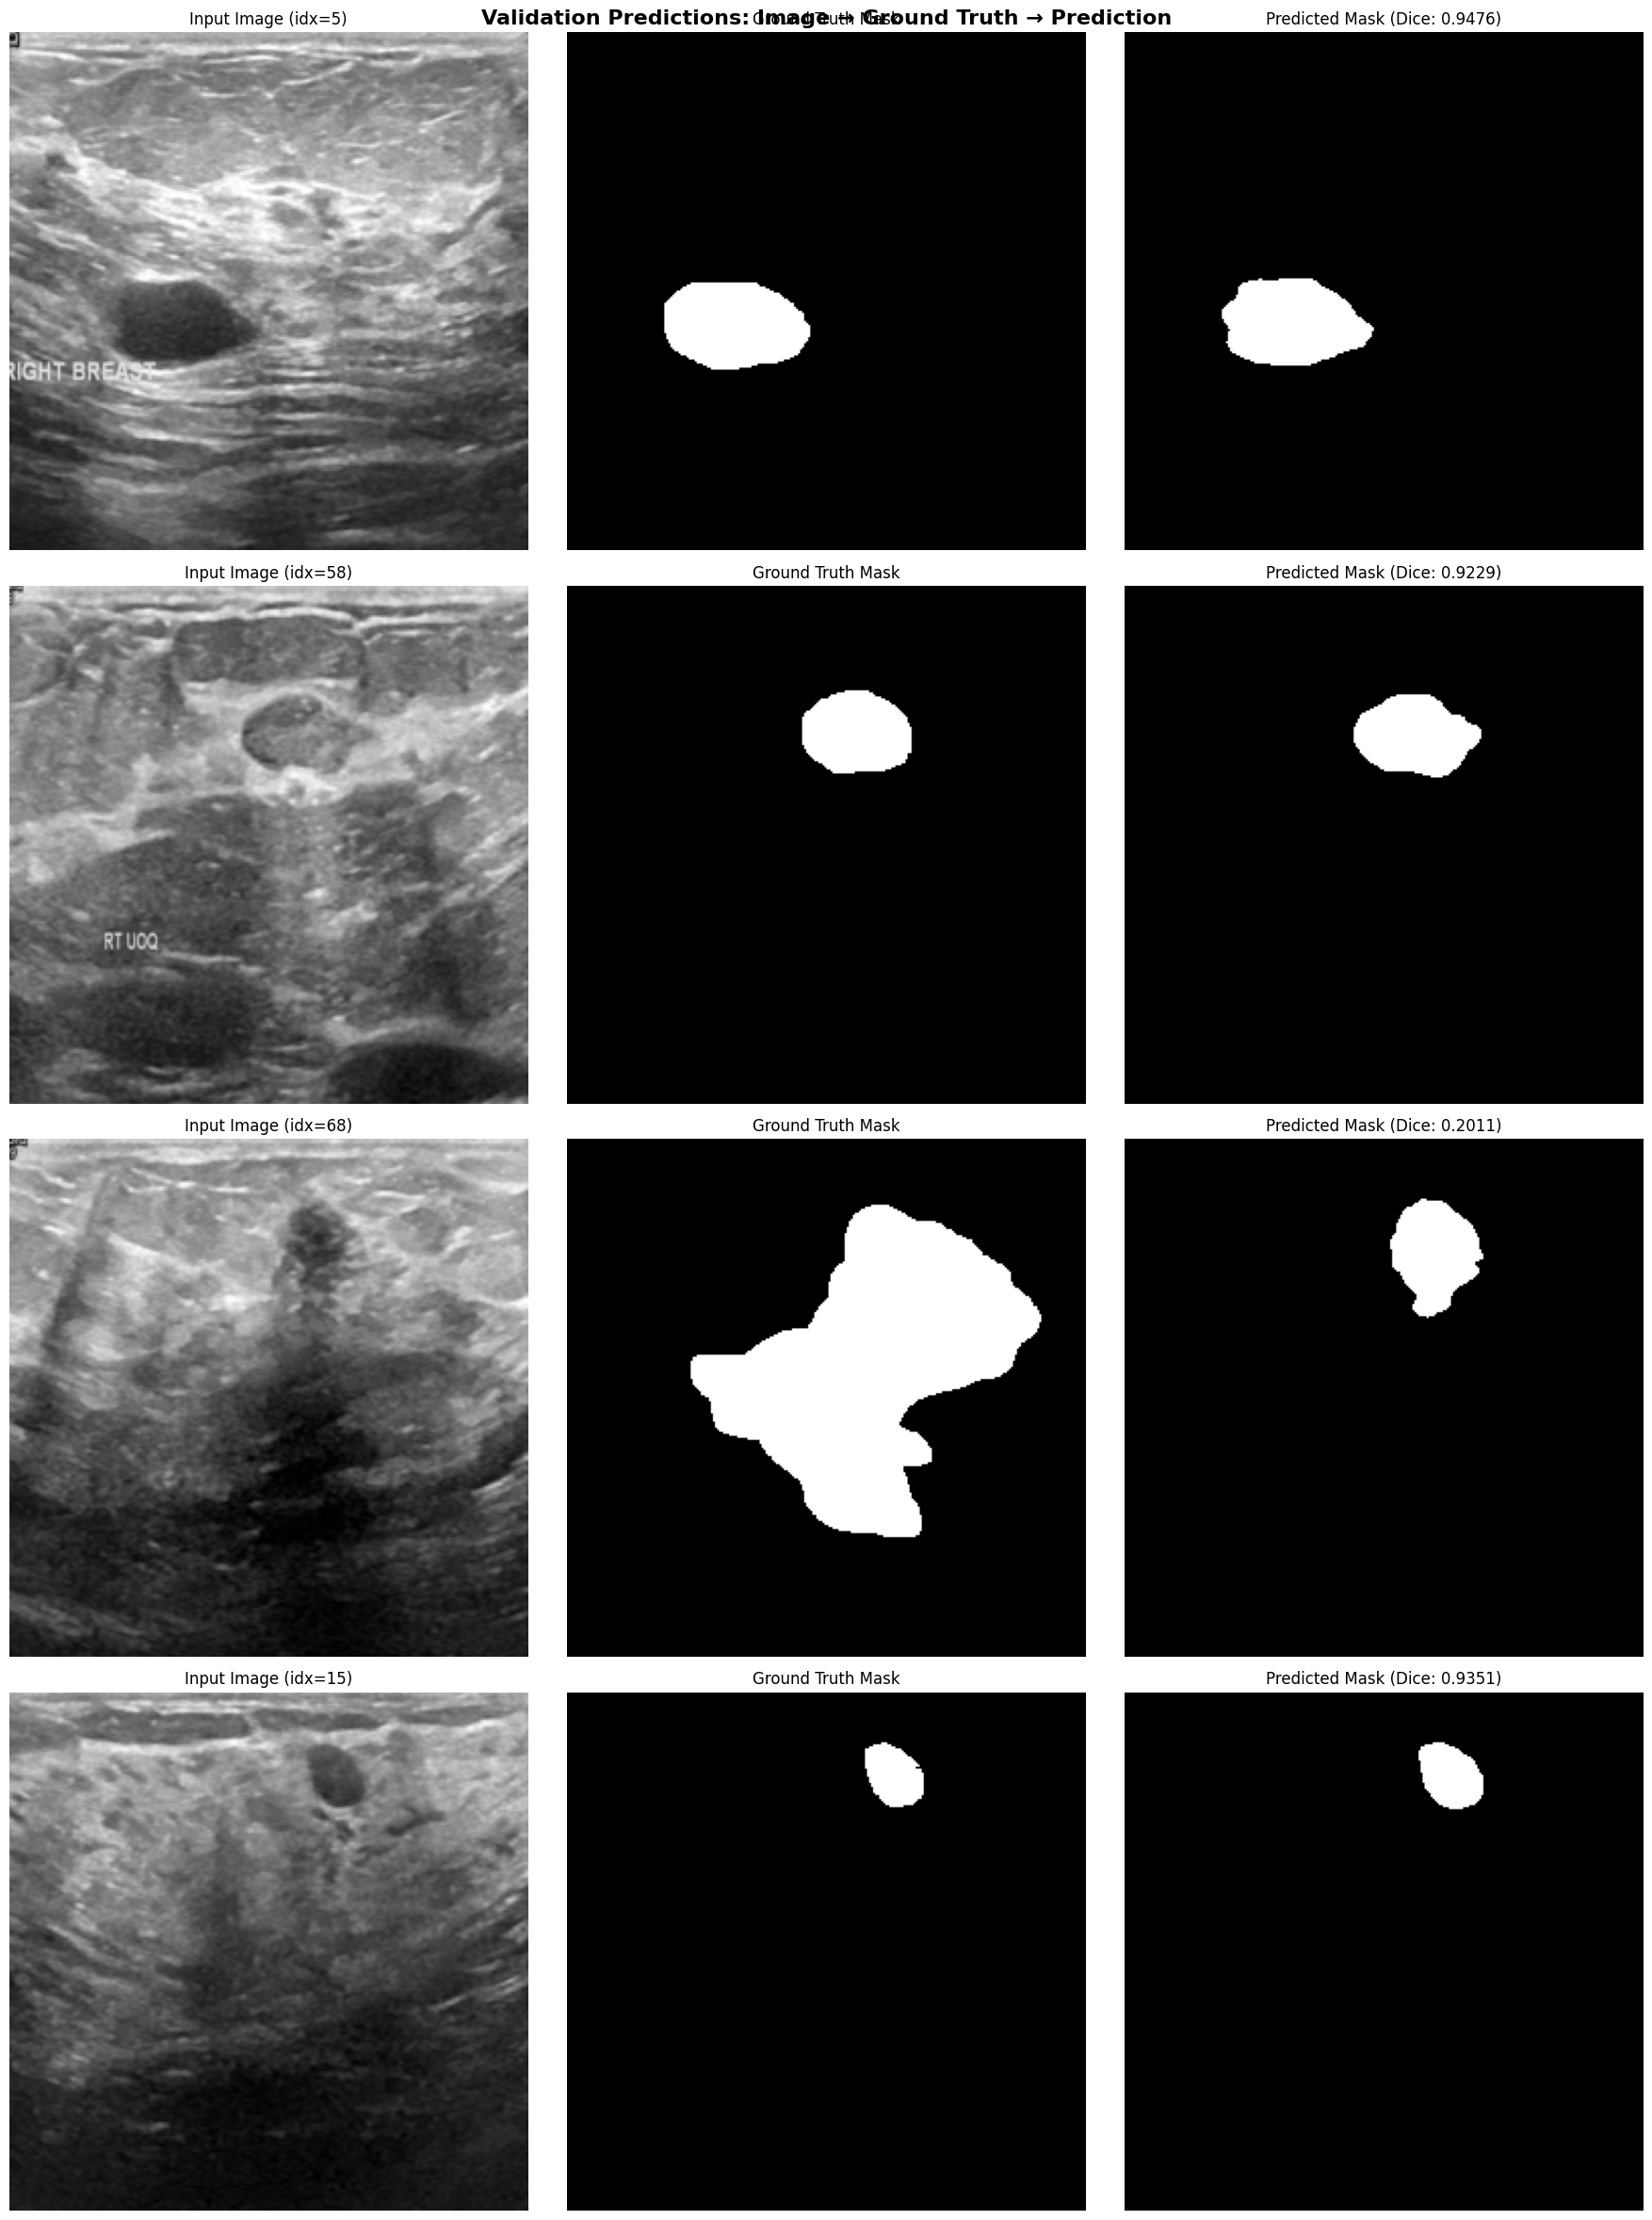

In [15]:
# Visualise Predictions vs Ground Truth
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225])

fig, axes = plt.subplots(4, 3, figsize=(18, 24))
sample_indices = random.sample(range(len(val_dataset)), 4)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        img, gt_mask = val_dataset[idx]
        img_input = img.unsqueeze(0).to(DEVICE)
        logits    = model(img_input)
        pred_mask = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

        # Un-normalise for display
        img_display = inv_norm(img).permute(1, 2, 0).clamp(0, 1).numpy()
        gt_display  = gt_mask.squeeze().numpy()

        d = dice_coefficient(logits.cpu(), gt_mask.unsqueeze(0)).item()

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'Input Image (idx={idx})', fontsize=12)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_display, cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask', fontsize=12)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f'Predicted Mask (Dice: {d:.4f})', fontsize=12)
        axes[i, 2].axis('off')

plt.suptitle('Validation Predictions: Image → Ground Truth → Prediction',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Prediction Generation on the Test Set


In [16]:
# RLE UTILITIES & TEST PREDICTION 

def mask_to_rle(mask):
    """Convert a binary mask (numpy, H×W) to RLE string.

    Pixels are read in column-major (Fortran) order:
    top→bottom, then left→right.
    """
    pixels = mask.T.flatten()  # transpose for column-major
    pixels = np.concatenate([[0], pixels, [0]])
    runs   = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(r) for r in runs)


def rle_to_mask(rle_string, shape):
    """Decode an RLE string back to a binary mask of given (H, W) shape."""
    s = rle_string.split()
    starts  = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends    = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape[1], shape[0]).T  # transpose back


# ── Verify RLE encode ↔ decode round-trip ─────────────────────────────────────
test_mask = np.zeros((128, 128), dtype=np.uint8)
test_mask[30:60, 40:80] = 1
rle_str = mask_to_rle(test_mask)
decoded = rle_to_mask(rle_str, (128, 128))
assert np.array_equal(test_mask, decoded), "RLE round-trip failed!"
print("[INFO] RLE encode/decode round-trip verified")


[INFO] RLE encode/decode round-trip verified


In [17]:
# Generate Predictions on Test Set

_state = torch.load(BEST_MODEL_PATH, map_location="cpu")
model.load_state_dict(_state)
model.eval()

test_csv  = pd.read_csv(os.path.join(TEST_DIR, "test.csv"))
image_ids = test_csv['image_id'].tolist()

submissions = []
print(f"[INFO] Generating predictions for {len(image_ids)} test images...")

with torch.no_grad():
    for i, (images, _) in enumerate(test_loader):
        images = images.to(DEVICE)

        if True: # Removed autocast for TPU
            logits = model(images)

        pred_mask = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

        # Resize prediction back to original image size for RLE
        img_id   = image_ids[i]
        orig_img = Image.open(os.path.join(TEST_DIR, "images", img_id))
        orig_w, orig_h = orig_img.size

        # Resize predicted mask to original dimensions
        pred_resized = np.array(
            Image.fromarray((pred_mask * 255).astype(np.uint8)).resize(
                (orig_w, orig_h), Image.NEAREST)
        ) > 127

        rle = mask_to_rle(pred_resized.astype(np.uint8))
        submissions.append({'image_id': img_id, 'rle_mask': rle})

        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(image_ids)} images")

submission_df = pd.DataFrame(submissions)
submission_df.to_csv("submission.csv", index=False)
print(f"[INFO] Submission saved → submission.csv ({len(submission_df)} rows)")
submission_df.head(10)


[INFO] Generating predictions for 94 test images...
  Processed 20/94 images
  Processed 40/94 images
  Processed 60/94 images
  Processed 80/94 images
[INFO] Submission saved → submission.csv (94 rows)


,image_id,rle_mask
0,sp_test_0001.png,214 5 228 93 679 5 693 93 1160 91 1625 91 2090...
1,sp_test_0002.png,116 13 692 13 1268 13 1844 11 2420 11 2996 11 ...
2,sp_test_0003.png,114974 2 115439 2 115897 13 116362 13 116827 1...
3,sp_test_0004.png,205275 22 205853 22 206431 22 207004 29 207582...
4,sp_test_0005.png,54534 7 55112 7 55690 7 56266 13 56844 13 5742...
5,sp_test_0006.png,67172 13 67576 13 67979 17 68383 17 68785 21 6...
6,sp_test_0007.png,182061 8 182524 8 182982 18 183445 18 183906 2...
7,sp_test_0008.png,85751 9 86219 9 86682 16 87150 16 87614 20 880...
8,sp_test_0009.png,103268 10 103694 10 104118 13 104544 13 104967...
9,sp_test_0010.png,193769 4 194340 4 194911 4 195477 11 196048 11...


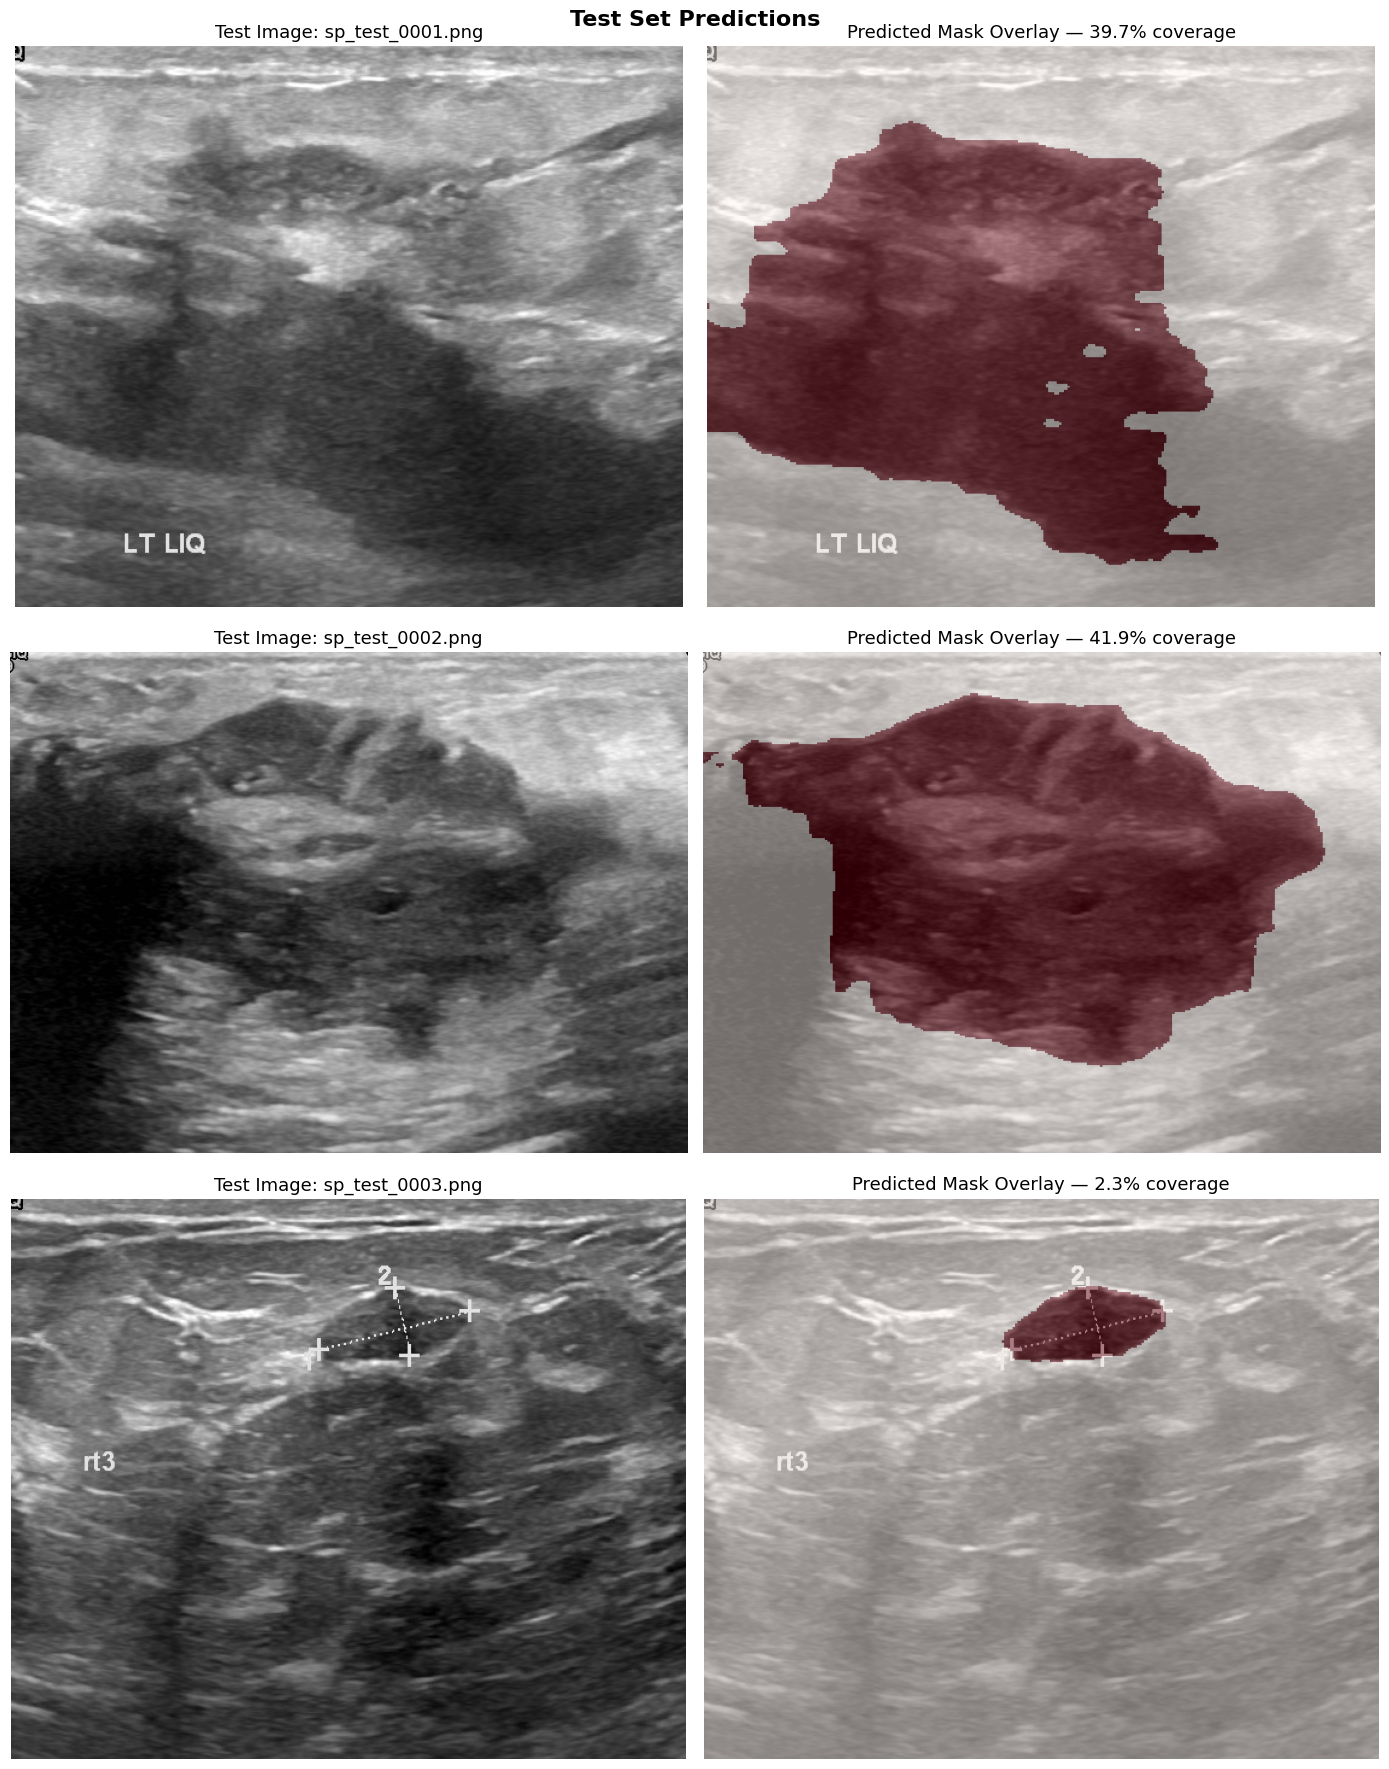

In [18]:
# ── Visualise Some Test Predictions ───────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for i in range(3):
    img_id = image_ids[i]
    orig_img = np.array(Image.open(os.path.join(TEST_DIR, "images", img_id)))

    # Decode the RLE from submission
    rle_str = submission_df[submission_df['image_id'] == img_id]['rle_mask'].values[0]
    if rle_str and str(rle_str) != 'nan' and len(str(rle_str).strip()) > 0:
        pred_mask = rle_to_mask(rle_str, (orig_img.shape[0], orig_img.shape[1]))
    else:
        pred_mask = np.zeros(orig_img.shape[:2], dtype=np.uint8)

    axes[i, 0].imshow(orig_img, cmap='gray' if orig_img.ndim == 2 else None)
    axes[i, 0].set_title(f'Test Image: {img_id}', fontsize=13)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(orig_img, cmap='gray' if orig_img.ndim == 2 else None)
    axes[i, 1].imshow(pred_mask, cmap='Reds', alpha=0.45)
    axes[i, 1].set_title(f'Predicted Mask Overlay — {pred_mask.sum()/pred_mask.size*100:.1f}% coverage', fontsize=13)
    axes[i, 1].axis('off')

plt.suptitle('Test Set Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


#  Model Visualization

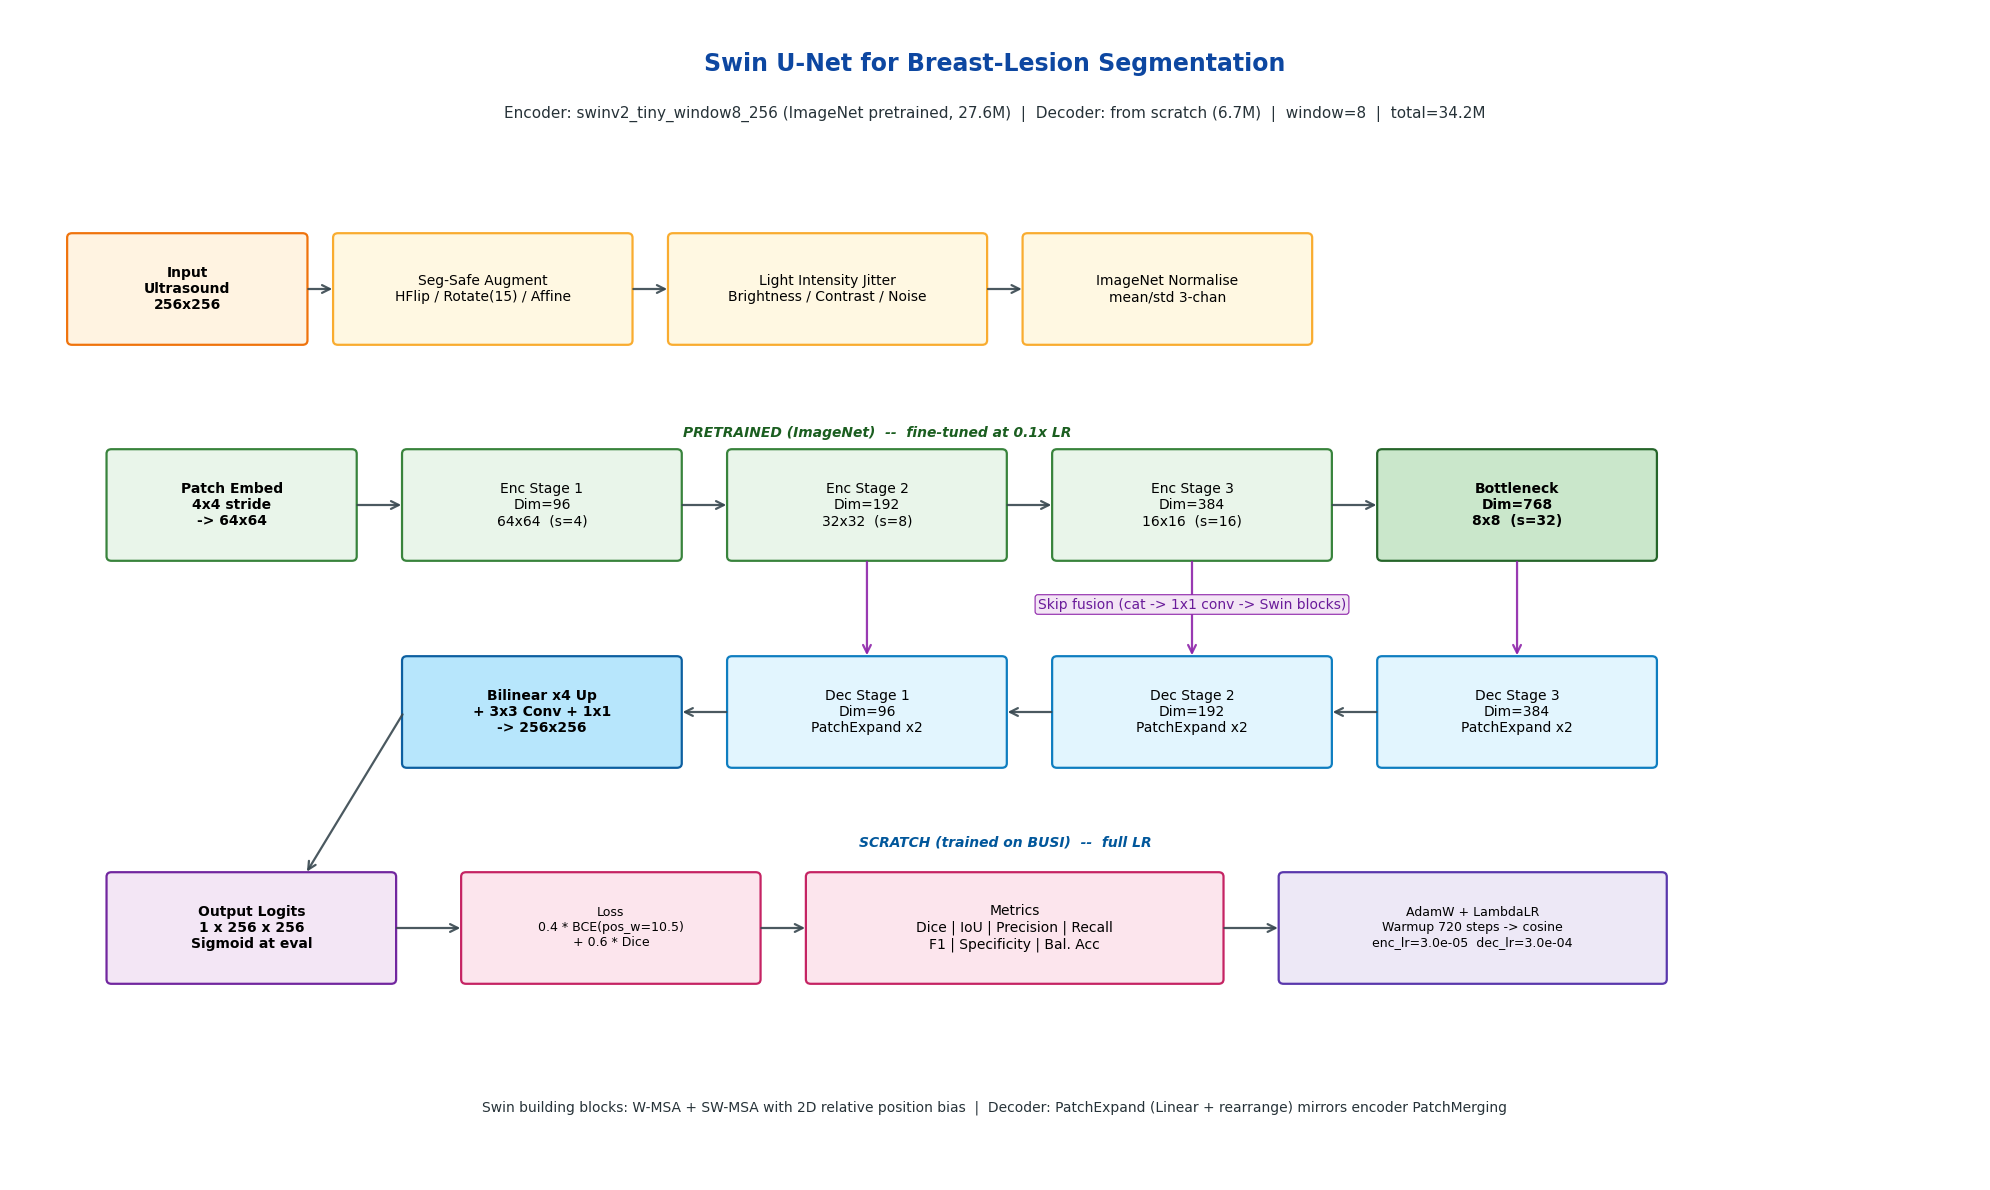

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def _draw_box(ax, x, y, w, h, text, color="#E3F2FD", edge="#1565C0",
              fs=10, weight="normal"):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=1.6, edgecolor=edge, facecolor=color, alpha=0.95,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text,
            ha="center", va="center", fontsize=fs, weight=weight)


def _arrow(ax, x1, y1, x2, y2, color="#37474F", lw=1.6, style="->"):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), arrowstyle=style,
        mutation_scale=14, linewidth=lw, color=color, alpha=0.9,
    ))


# ── Pull the live config from the trained model ──────────────────────────────
enc_dims = list(model._encoder_dims)                          # e.g. [96, 192, 384, 768]
c1, c2, c3, c4 = enc_dims
res_in = IMG_SIZE
res_map = [res_in // 4, res_in // 8, res_in // 16, res_in // 32]

total_params = sum(p.numel() for p in model.parameters())
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = total_params - enc_params

try:
    encoder_tag = PRETRAINED_ENCODER_NAME
except NameError:
    encoder_tag = "pretrained Swin"


fig, ax = plt.subplots(figsize=(20, 12))
ax.set_xlim(0, 20); ax.set_ylim(0, 13); ax.axis("off")

ax.text(
    10, 12.4,
    f"Swin U-Net for Breast-Lesion Segmentation",
    ha="center", va="center", fontsize=17, weight="bold", color="#0D47A1",
)
ax.text(
    10, 11.85,
    f"Encoder: {encoder_tag} (ImageNet pretrained, {enc_params/1e6:.1f}M)  |  "
    f"Decoder: from scratch ({dec_params/1e6:.1f}M)  |  "
    f"window={SWIN_WINDOW_SIZE}  |  total={total_params/1e6:.1f}M",
    ha="center", va="center", fontsize=11, color="#263238",
)

# ── Input + augmentation lane ────────────────────────────────────────────────
_draw_box(ax, 0.6, 9.3, 2.4, 1.2,
          f"Input\nUltrasound\n{res_in}x{res_in}",
          color="#FFF3E0", edge="#EF6C00", fs=10, weight="bold")
_draw_box(ax, 3.3, 9.3, 3.0, 1.2,
          "Seg-Safe Augment\nHFlip / Rotate(15) / Affine",
          color="#FFF8E1", edge="#F9A825")
_draw_box(ax, 6.7, 9.3, 3.2, 1.2,
          "Light Intensity Jitter\nBrightness / Contrast / Noise",
          color="#FFF8E1", edge="#F9A825")
_draw_box(ax, 10.3, 9.3, 2.9, 1.2,
          "ImageNet Normalise\nmean/std 3-chan",
          color="#FFF8E1", edge="#F9A825")
_arrow(ax, 3.0, 9.9, 3.3, 9.9)
_arrow(ax, 6.3, 9.9, 6.7, 9.9)
_arrow(ax, 9.9, 9.9, 10.3, 9.9)

# ── Encoder row (pretrained SwinV2-Tiny) ─────────────────────────────────────
_draw_box(ax, 1.0, 6.9, 2.5, 1.2,
          f"Patch Embed\n4x4 stride\n-> {res_map[0]}x{res_map[0]}",
          color="#E8F5E9", edge="#2E7D32", weight="bold")
_draw_box(ax, 4.0, 6.9, 2.8, 1.2,
          f"Enc Stage 1\nDim={c1}\n{res_map[0]}x{res_map[0]}  (s=4)",
          color="#E8F5E9", edge="#2E7D32")
_draw_box(ax, 7.3, 6.9, 2.8, 1.2,
          f"Enc Stage 2\nDim={c2}\n{res_map[1]}x{res_map[1]}  (s=8)",
          color="#E8F5E9", edge="#2E7D32")
_draw_box(ax, 10.6, 6.9, 2.8, 1.2,
          f"Enc Stage 3\nDim={c3}\n{res_map[2]}x{res_map[2]}  (s=16)",
          color="#E8F5E9", edge="#2E7D32")
_draw_box(ax, 13.9, 6.9, 2.8, 1.2,
          f"Bottleneck\nDim={c4}\n{res_map[3]}x{res_map[3]}  (s=32)",
          color="#C8E6C9", edge="#1B5E20", weight="bold")

for x in [3.5, 6.8, 10.1, 13.4]:
    _arrow(ax, x, 7.5, x + 0.5, 7.5)

ax.text(8.8, 8.3, "PRETRAINED (ImageNet)  --  fine-tuned at 0.1x LR",
        ha="center", va="center", fontsize=10, color="#1B5E20",
        style="italic", weight="bold")

# ── Decoder row (from scratch, mirrors encoder)
_draw_box(ax, 13.9, 4.6, 2.8, 1.2,
          f"Dec Stage 3\nDim={c3}\nPatchExpand x2",
          color="#E1F5FE", edge="#0277BD")
_draw_box(ax, 10.6, 4.6, 2.8, 1.2,
          f"Dec Stage 2\nDim={c2}\nPatchExpand x2",
          color="#E1F5FE", edge="#0277BD")
_draw_box(ax, 7.3, 4.6, 2.8, 1.2,
          f"Dec Stage 1\nDim={c1}\nPatchExpand x2",
          color="#E1F5FE", edge="#0277BD")
_draw_box(ax, 4.0, 4.6, 2.8, 1.2,
          f"Bilinear x4 Up\n+ 3x3 Conv + 1x1\n-> {res_in}x{res_in}",
          color="#B3E5FC", edge="#01579B", weight="bold")

for x in [13.9, 10.6, 7.3]:
    _arrow(ax, x, 5.2, x - 0.5, 5.2)

ax.text(10.1, 3.75, "SCRATCH (trained on BUSI)  --  full LR",
        ha="center", va="center", fontsize=10, color="#01579B",
        style="italic", weight="bold")

# ── Skip connections (same-resolution fusion via cat + 1x1 conv) ─────────────
_arrow(ax, 15.3, 6.9, 15.3, 5.8, color="#8E24AA", lw=1.6)
_arrow(ax, 12.0, 6.9, 12.0, 5.8, color="#8E24AA", lw=1.6)
_arrow(ax, 8.7, 6.9, 8.7, 5.8, color="#8E24AA", lw=1.6)
ax.text(12.0, 6.35, "Skip fusion (cat -> 1x1 conv -> Swin blocks)",
        color="#6A1B9A", fontsize=10, ha="center",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="#F3E5F5",
                  edgecolor="#8E24AA", linewidth=0.8))

# ── Output + loss/metrics lane ──────────────────────────────────────────────
_draw_box(ax, 1.0, 2.2, 2.9, 1.2,
          f"Output Logits\n1 x {res_in} x {res_in}\nSigmoid at eval",
          color="#F3E5F5", edge="#6A1B9A", weight="bold")
_arrow(ax, 4.0, 5.2, 3.0, 3.4)

_draw_box(ax, 4.6, 2.2, 3.0, 1.2,
          f"Loss\n0.4 * BCE(pos_w={_pos_weight:.1f})\n+ 0.6 * Dice",
          color="#FCE4EC", edge="#C2185B", fs=9)
_draw_box(ax, 8.1, 2.2, 4.2, 1.2,
          "Metrics\nDice | IoU | Precision | Recall\nF1 | Specificity | Bal. Acc",
          color="#FCE4EC", edge="#C2185B")
_draw_box(ax, 12.9, 2.2, 3.9, 1.2,
          f"AdamW + LambdaLR\nWarmup {warmup_steps} steps -> cosine\n"
          f"enc_lr={LEARNING_RATE*ENCODER_LR_FACTOR:.1e}  dec_lr={LEARNING_RATE:.1e}",
          color="#EDE7F6", edge="#512DA8", fs=9)

_arrow(ax, 3.9, 2.8, 4.6, 2.8)
_arrow(ax, 7.6, 2.8, 8.1, 2.8)
_arrow(ax, 12.3, 2.8, 12.9, 2.8)

ax.text(
    10, 0.8,
    "Swin building blocks: W-MSA + SW-MSA with 2D relative position bias  |  "
    "Decoder: PatchExpand (Linear + rearrange) mirrors encoder PatchMerging",
    ha="center", va="center", fontsize=10, color="#263238",
)

plt.tight_layout(); plt.show()
